# V9 — Player Fingerprint DeepSets / Attention + LightGBM

Objectif : tester rapidement une représentation neuronale du joueur à partir de ses parties, sans remplacer les baselines V8.

Ce notebook fait volontairement peu d'expériences pour rester exécutable :

- `N = [1, 3, 5, 10, 30]` parties par joueur ;
- split **par joueur** pour éviter le leakage ;
- pas de `opponent_elo`, `elo_diff`, ni variables Elo adversaire ;
- DeepSets mean pooling ;
- DeepSets attention pooling ;
- LightGBM V8 baseline ;
- LightGBM V8 + embeddings attention.

> Important : pour l'expérience N=5, les features V8 et l'embedding sont calculés avec les mêmes 5 parties seulement. L'embedding ne doit pas utiliser les 30 parties si on prétend prédire avec 5 parties.


**Version corrigée FIXED2** : correction directe de `game_rich`, `moves_v8`, cible `elo`, et suppression de l'appel prématuré `build_player_features_v8(game_rich)` qui causait l'erreur.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Optionnel : montage Google Drive si vous êtes sur Colab.
# En local/Jupyter, cette cellule ne plante plus.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Pas dans Google Colab : montage Drive ignoré.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ============================================================
# 0. Imports & configuration rapide
# ============================================================

import os, sys, random, warnings
from pathlib import Path
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM non installé. Installez-le avec: pip install lightgbm")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost non installé. Ce n'est pas grave pour l'expérience principale.")

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠️ PyTorch non installé. Installez-le avec: pip install torch")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
DEVICE = 'cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_STATE)

# ============================================================
# Chemins : adaptez BASE_DIR si nécessaire
# ============================================================
IN_COLAB = 'google.colab' in sys.modules
BASE_DIR = Path('/content/drive/MyDrive/Data_Pmind_700-30') if IN_COLAB else Path(r'G:\Mon Drive\Data_Pmind_700-30')

# Vous pouvez retirer rapid si vous n'avez pas les fichiers.
CADENCES = ['bullet', 'blitz', 'rapid']
CADENCE_DATA_DIRS = {c: BASE_DIR / c for c in CADENCES}

# Valeurs N choisies pour aller vite mais répondre à la question.
N_VALUES = [1, 3, 5, 10, 30]
TRAIN_N_CHOICES = [1, 3, 5, 10, 30]
MAX_N = max(N_VALUES)

# Entraînement neural : réglages volontairement modestes.
BATCH_SIZE = 64
EPOCHS = 80
PATIENCE = 12
LR = 1e-3
WEIGHT_DECAY = 1e-4
EMB_DIM = 48
HIDDEN_DIM = 96
DROPOUT = 0.20

# Pour aller encore plus vite pendant les premiers tests, mettez True.
FAST_DEBUG = False
DEBUG_MAX_PLAYERS_PER_CADENCE = 180

# Seuils V8 repris de vos notebooks.
EVAL_CAP = 900
LOSS_CAP = 600
THRESHOLD_WIN = 150
THRESHOLD_LOSE = -150
LOW_CLOCK_RATIO = 0.20


Device: cpu


## 1. Fonctions V8 reprises des anciens notebooks

Les fonctions suivantes reprennent votre logique V8 : nettoyage avec `cp_loss_clean`, features game-level, enrichissement avec métadonnées, puis agrégation player-level.


In [5]:
def _read_csv_if_exists(path: Path) -> Optional[pd.DataFrame]:
    """Lit un CSV s'il existe, sinon retourne None."""
    if path.exists():
        return pd.read_csv(path)
    return None


def _first_existing_column(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _build_games_from_available(
    cadence: str,
    moves_cad: pd.DataFrame,
    summary_cad: Optional[pd.DataFrame],
    players_cad: pd.DataFrame,
) -> pd.DataFrame:
    """
    Fallback pour une cadence sans fichier games.csv.
    On reconstruit uniquement la table game-level minimale attendue par le notebook,
    à partir de summary.csv puis moves.csv si les colonnes existent.
    """
    required_cols = [
        'game_id', 'target_name', 'speed', 'time_control', 'target_elo',
        'target_result', 'target_score', 'opening_eco', 'opening_ply',
        'ply_count', 'target_color', 'date_utc'
    ]

    sources = [df for df in [summary_cad, moves_cad] if df is not None and 'game_id' in df.columns]
    if not sources:
        raise FileNotFoundError(
            f"{cadence}: games.csv absent et impossible de reconstruire le game-level "
            "car aucun game_id n'a été trouvé dans summary.csv ou moves.csv."
        )

    base = sources[0].copy()
    if base['game_id'].duplicated().any():
        # Une ligne par partie ; first() suffit pour les métadonnées constantes.
        base = base.groupby('game_id', as_index=False).first()

    games_cad = pd.DataFrame({'game_id': base['game_id']})

    column_map = {
        'target_name':   ['target_name', 'username', 'player', 'target_username'],
        'time_control':  ['time_control', 'tc', 'clock'],
        'target_elo':    ['target_elo', 'elo', 'player_elo'],
        'target_result': ['target_result', 'result'],
        'target_score':  ['target_score', 'score'],
        'opening_eco':   ['opening_eco', 'eco'],
        'opening_ply':   ['opening_ply'],
        'ply_count':     ['ply_count', 'plies', 'num_plies'],
        'target_color':  ['target_color', 'player_color', 'color'],
        'date_utc':      ['date_utc', 'created_at', 'date'],
    }

    for out_col, candidates in column_map.items():
        found = _first_existing_column(base, candidates)
        games_cad[out_col] = base[found] if found is not None else np.nan

    # Si ply_count n'existe pas côté summary, le reconstruire depuis moves.
    if games_cad['ply_count'].isna().all() and 'ply' in moves_cad.columns:
        ply_count = moves_cad.groupby('game_id')['ply'].max().add(1).rename('ply_count_rebuilt')
        games_cad = games_cad.merge(ply_count, on='game_id', how='left')
        games_cad['ply_count'] = games_cad['ply_count_rebuilt']
        games_cad = games_cad.drop(columns=['ply_count_rebuilt'])

    games_cad['speed'] = cadence

    # Valeurs par défaut non analytiques, uniquement pour garder le pipeline inchangé.
    default_tc = {'bullet': '60+0', 'blitz': '180+0', 'rapid': '600+0'}
    games_cad['time_control'] = games_cad['time_control'].fillna(default_tc.get(cadence, ''))
    games_cad['opening_eco'] = games_cad['opening_eco'].fillna('?')
    games_cad['opening_ply'] = pd.to_numeric(games_cad['opening_ply'], errors='coerce')
    games_cad['ply_count'] = pd.to_numeric(games_cad['ply_count'], errors='coerce')
    games_cad['target_score'] = pd.to_numeric(games_cad['target_score'], errors='coerce')
    games_cad['target_elo'] = pd.to_numeric(games_cad['target_elo'], errors='coerce')

    missing_core = [c for c in ['target_name'] if games_cad[c].isna().all()]
    if missing_core:
        raise ValueError(
            f"{cadence}: games.csv absent et colonne(s) impossible(s) à reconstruire : {missing_core}. "
            "Ajoute ces colonnes dans summary.csv ou fournis games.csv."
        )

    return games_cad[required_cols]


def _force_cadence(df: pd.DataFrame, cadence: str) -> pd.DataFrame:
    df = df.copy()
    df['speed'] = cadence
    return df


def load_cadence_data(cadence_dirs: dict[str, Path]):
    """Charge bullet/blitz/rapid depuis des dossiers séparés et concatène les tables."""
    all_moves, all_games, all_summary, all_players = [], [], [], []

    for cadence in CADENCES:
        data_dir = cadence_dirs[cadence]
        moves_path   = data_dir / 'moves.csv'
        games_path   = data_dir / 'games.csv'
        summary_path = data_dir / 'summary.csv'
        players_path = data_dir / 'players.csv'

        moves_cad = _read_csv_if_exists(moves_path)
        summary_cad = _read_csv_if_exists(summary_path)
        players_cad = _read_csv_if_exists(players_path)

        if moves_cad is None:
            raise FileNotFoundError(f"{cadence}: fichier introuvable -> {moves_path}")
        if players_cad is None:
            raise FileNotFoundError(f"{cadence}: fichier introuvable -> {players_path}")
        if summary_cad is None:
            summary_cad = pd.DataFrame()

        games_cad = _read_csv_if_exists(games_path)
        if games_cad is None:
            print(f"⚠ {cadence}: games.csv absent — reconstruction minimale depuis summary/moves")
            games_cad = _build_games_from_available(cadence, moves_cad, summary_cad, players_cad)

        moves_cad   = _force_cadence(moves_cad, cadence)
        games_cad   = _force_cadence(games_cad, cadence)
        summary_cad = _force_cadence(summary_cad, cadence) if len(summary_cad) else summary_cad
        players_cad = _force_cadence(players_cad, cadence)

        all_moves.append(moves_cad)
        all_games.append(games_cad)
        all_summary.append(summary_cad)
        all_players.append(players_cad)

        print(f"\n[{cadence.upper()}] {data_dir}")
        print(f"  moves   : {moves_cad.shape[0]:>8,} × {moves_cad.shape[1]}")
        print(f"  games   : {games_cad.shape[0]:>8,} × {games_cad.shape[1]}")
        print(f"  players : {players_cad.shape[0]:>8,} × {players_cad.shape[1]}")

    moves   = pd.concat(all_moves, ignore_index=True)
    games   = pd.concat(all_games, ignore_index=True)
    summary = pd.concat([df for df in all_summary if len(df)], ignore_index=True) if any(len(df) for df in all_summary) else pd.DataFrame()
    players = pd.concat(all_players, ignore_index=True)

    print(f"\n✓ Chargement concaténé OK")
    print(f"moves   : {moves.shape[0]:>8,} × {moves.shape[1]}")
    print(f"games   : {games.shape[0]:>8,} × {games.shape[1]}")
    print(f"players : {players.shape[0]:>8,} × {players.shape[1]}")
    return moves, games, summary, players




In [6]:
def clean_moves(moves: pd.DataFrame) -> pd.DataFrame:
    """
    Nettoyage moves — taxonomie recalculée sur cp_loss_clean.
    CORRECTION : is_good / is_blunder / etc. utilisent cp_loss_clean (pas loss_capped).
    """
    df = moves.copy()

    df['eval_before_capped'] = df['eval_white_before'].clip(-EVAL_CAP, EVAL_CAP)
    df['eval_after_capped']  = df['eval_white_after'].clip(-EVAL_CAP, EVAL_CAP)

    # Perte reconstruite (diagnostic uniquement)
    df['loss_signed'] = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'] - df['eval_after_capped'],
        df['eval_after_capped']  - df['eval_before_capped']
    )
    df['loss_capped']   = df['loss_signed'].clip(0, LOSS_CAP)
    df['cp_loss_clean'] = df['cp_loss'].abs().clip(0, LOSS_CAP)
    df['eval_abs']      = df['eval_before_capped'].abs()

    eval_for_player = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'], -df['eval_before_capped']
    )
    df['is_winning'] = (eval_for_player > THRESHOLD_WIN).astype(int)
    df['is_equal']   = ((eval_for_player >= THRESHOLD_LOSE) &
                        (eval_for_player <= THRESHOLD_WIN)).astype(int)
    df['is_losing']  = (eval_for_player < THRESHOLD_LOSE).astype(int)

    # Taxonomie sur cp_loss_clean
    df['is_good']       = (df['cp_loss_clean'] < 50).astype(int)
    df['is_inaccuracy'] = ((df['cp_loss_clean'] >= 50)  & (df['cp_loss_clean'] < 100)).astype(int)
    df['is_mistake']    = ((df['cp_loss_clean'] >= 100) & (df['cp_loss_clean'] < 200)).astype(int)
    df['is_blunder']    = (df['cp_loss_clean'] >= 200).astype(int)
    df['is_error']      = (df['cp_loss_clean'] >= 50).astype(int)

    mask_not_target = ~df['is_target_move']
    for col in ['is_good', 'is_inaccuracy', 'is_mistake', 'is_blunder',
                'is_error', 'cp_loss_clean', 'loss_capped']:
        df.loc[mask_not_target, col] = np.nan

    df['is_opening']    = (df['phase'] == 'opening').astype(int)
    df['is_middlegame'] = (df['phase'] == 'middlegame').astype(int)
    df['is_endgame']    = (df['phase'] == 'endgame').astype(int)

    df['time_spent_s'] = df['time_spent_cs'].fillna(0) / 100
    df['clock_s']      = df['clock_before_cs'].fillna(df['clock_before_cs'].median()) / 100
    df['time_log']     = np.log1p(df['time_spent_s'])

    df['is_capture']   = df['is_capture'].astype(int)
    df['is_check']     = df['is_check'].astype(int)
    df['is_castle']    = df['is_castle'].astype(int)
    df['is_promotion'] = df['is_promotion'].astype(int)
    df['move_number']  = (df['ply'] + 1) // 2

    print(f"✓ Moves nettoyés : {len(df):,} lignes")
    print(f"  Blunder rate (cp_loss_clean) : "
          f"{df[df['is_target_move']]['is_blunder'].mean()*100:.1f}%")
    return df



In [7]:
def laplace_smooth(k, n, alpha=1.0):
    """Lissage Laplace : (k + alpha) / (n + 2*alpha). Robuste aux petits n."""
    return (k + alpha) / (n + 2 * alpha)


def build_game_features_v8(moves_df: pd.DataFrame) -> pd.DataFrame:
    m = moves_df[moves_df['is_target_move']].copy()
    m['loss_main']     = m['cp_loss_clean']
    m['loss_log_main'] = np.log1p(m['loss_main'])

    max_clock_per_game = m.groupby('game_id')['clock_s'].transform('max')
    m['is_low_clock']  = (m['clock_s'] < LOW_CLOCK_RATIO * max_clock_per_game).astype(int)
    m['is_critical']   = ((m['is_error'] == 1) | (m['eval_abs'] > 300)).astype(int)

    agg = {}

    # ── Qualité de base ───────────────────────────────────────────────────────
    agg['n_moves']         = ('loss_main', 'count')
    agg['loss_mean']       = ('loss_main', 'mean')
    agg['loss_median']     = ('loss_main', 'median')
    agg['loss_std']        = ('loss_main', 'std')
    agg['loss_p25']        = ('loss_main', lambda x: x.quantile(0.25))
    agg['loss_p75']        = ('loss_main', lambda x: x.quantile(0.75))
    agg['loss_p90']        = ('loss_main', lambda x: x.quantile(0.90))
    agg['loss_iqr']        = ('loss_main', lambda x: x.quantile(0.75) - x.quantile(0.25))
    agg['loss_max']        = ('loss_main', 'max')
    agg['loss_log_mean']   = ('loss_log_main', 'mean')
    agg['rate_good']       = ('is_good',       'mean')
    agg['rate_inaccuracy'] = ('is_inaccuracy',  'mean')
    agg['rate_mistake']    = ('is_mistake',     'mean')
    agg['rate_blunder']    = ('is_blunder',     'mean')
    agg['rate_error']      = ('is_error',       'mean')
    agg['n_blunders']      = ('is_blunder',     'sum')
    agg['n_mistakes']      = ('is_mistake',     'sum')
    agg['n_errors']        = ('is_error',       'sum')

    # Taux lissés Laplace
    agg['rate_blunder_smooth'] = ('is_blunder', lambda x: laplace_smooth(x.sum(), len(x)))
    agg['rate_mistake_smooth'] = ('is_mistake', lambda x: laplace_smooth(x.sum(), len(x)))
    agg['rate_error_smooth']   = ('is_error',   lambda x: laplace_smooth(x.sum(), len(x)))
    agg['rate_loss_gt100']     = ('loss_main', lambda x: (x > 100).mean())
    agg['rate_loss_gt200']     = ('loss_main', lambda x: (x > 200).mean())

    # ── Temps ─────────────────────────────────────────────────────────────────
    agg['time_mean_s']   = ('time_spent_s', 'mean')
    agg['time_median_s'] = ('time_spent_s', 'median')
    agg['time_std_s']    = ('time_spent_s', 'std')
    agg['time_iqr_s']    = ('time_spent_s', lambda x: x.quantile(0.75) - x.quantile(0.25))
    agg['time_p90_s']    = ('time_spent_s', lambda x: x.quantile(0.90))
    agg['time_log_mean'] = ('time_log', 'mean')
    agg['clock_mean_s']  = ('clock_s', 'mean')

    agg['time_mean_on_error']   = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_error'] == 1].mean())
    agg['time_mean_on_blunder'] = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_blunder'] == 1].mean())
    agg['time_mean_on_good']    = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_good'] == 1].mean())

    agg['time_pressure_by_phase_opening']    = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean())
    agg['time_pressure_by_phase_middlegame'] = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean())
    agg['time_pressure_by_phase_endgame']    = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean())

    agg['good_fast_move_rate']        = ('is_good', lambda x: (x[m.loc[x.index, 'time_spent_s'] <= 2] == 1).sum() / (len(x) + 1e-9))
    agg['good_fast_move_rate_smooth'] = ('is_good', lambda x: laplace_smooth((x[m.loc[x.index, 'time_spent_s'] <= 2] == 1).sum(), len(x)))

    agg['blunder_low_time_rate']        = ('is_blunder', lambda x: (x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum() / (len(x) + 1e-9))
    agg['blunder_low_time_rate_smooth'] = ('is_blunder', lambda x: laplace_smooth((x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum(), len(x)))

    agg['time_used_when_equal']       = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['avg_time_on_critical_moves'] = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_critical'] == 1].mean())

    # ── Contexte positionnel ──────────────────────────────────────────────────
    agg['loss_when_winning'] = ('loss_main', lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean())
    agg['loss_when_equal']   = ('loss_main', lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['loss_when_losing']  = ('loss_main', lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean())

    agg['rate_blunder_when_equal_smooth']   = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_equal'] == 1].sum(),   (m.loc[x.index, 'is_equal'] == 1).sum()))
    agg['rate_blunder_when_winning_smooth'] = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_winning'] == 1].sum(), (m.loc[x.index, 'is_winning'] == 1).sum()))
    agg['rate_blunder_when_losing_smooth']  = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_losing'] == 1].sum(),  (m.loc[x.index, 'is_losing'] == 1).sum()))

    # Counts (dénominateurs)
    agg['n_moves_winning']   = ('is_winning',   lambda x: (m.loc[x.index, 'is_winning'] == 1).sum())
    agg['n_moves_equal']     = ('is_equal',     lambda x: (m.loc[x.index, 'is_equal'] == 1).sum())
    agg['n_moves_losing']    = ('is_losing',    lambda x: (m.loc[x.index, 'is_losing'] == 1).sum())
    agg['n_moves_opening']   = ('is_opening',   lambda x: (m.loc[x.index, 'is_opening'] == 1).sum())
    agg['n_moves_low_clock'] = ('is_low_clock', lambda x: (m.loc[x.index, 'is_low_clock'] == 1).sum())

    # Taux blunder par phase — lissés
    agg['rate_blunder_opening_smooth']    = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_opening'] == 1].sum(),    (m.loc[x.index, 'is_opening'] == 1).sum()))
    agg['rate_blunder_middlegame_smooth'] = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_middlegame'] == 1].sum(), (m.loc[x.index, 'is_middlegame'] == 1).sum()))
    agg['rate_mistake_opening_smooth']    = ('is_mistake', lambda x: laplace_smooth(x[m.loc[x.index, 'is_opening'] == 1].sum(),    (m.loc[x.index, 'is_opening'] == 1).sum()))
    agg['rate_mistake_middlegame_smooth'] = ('is_mistake', lambda x: laplace_smooth(x[m.loc[x.index, 'is_middlegame'] == 1].sum(), (m.loc[x.index, 'is_middlegame'] == 1).sum()))

    # ── Style ─────────────────────────────────────────────────────────────────
    agg['rate_capture']   = ('is_capture',   'mean')
    agg['rate_check']     = ('is_check',     'mean')
    agg['rate_castle']    = ('is_castle',    'sum')
    agg['rate_promotion'] = ('is_promotion', 'mean')

    game_features = m.groupby('game_id').agg(**agg).reset_index()

    # ── Qualité par phase (mean + median + std + IQR + p90) ──────────────────
    for phase in ['opening', 'middlegame', 'endgame']:
        sub = (
            m[m['phase'] == phase]
            .groupby('game_id')
            .agg(
                **{
                    f'loss_{phase}_mean':   pd.NamedAgg('loss_main', 'mean'),
                    f'loss_{phase}_median': pd.NamedAgg('loss_main', 'median'),
                    f'loss_{phase}_std':    pd.NamedAgg('loss_main', 'std'),
                    f'loss_{phase}_iqr':    pd.NamedAgg('loss_main', lambda x: x.quantile(0.75) - x.quantile(0.25)),
                    f'loss_{phase}_p90':    pd.NamedAgg('loss_main', lambda x: x.quantile(0.90)),
                }
            )
            .reset_index()
        )
        game_features = game_features.merge(sub, on='game_id', how='left')

        sub_t = (
            m[m['phase'] == phase]
            .groupby('game_id')
            .agg(
                **{
                    f'time_{phase}_mean_s':   pd.NamedAgg('time_spent_s', 'mean'),
                    f'time_{phase}_median_s': pd.NamedAgg('time_spent_s', 'median'),
                }
            )
            .reset_index()
        )
        game_features = game_features.merge(sub_t, on='game_id', how='left')

    # ── Drift intra-partie ────────────────────────────────────────────────────
    def half_loss_diff(g):
        mid    = len(g) // 2
        first  = g.iloc[:mid]['loss_main'].mean() if mid > 0      else np.nan
        second = g.iloc[mid:]['loss_main'].mean() if mid < len(g) else np.nan
        return second - first

    drift = m.groupby('game_id').apply(half_loss_diff).rename('loss_drift_end_vs_start')
    game_features = game_features.merge(drift, on='game_id', how='left')

    # ── Temps avant blunder ───────────────────────────────────────────────────
    def time_before_blunder(g):
        times = []
        for idx in g[g['is_blunder'] == 1].index:
            pos = g.index.get_loc(idx)
            if pos > 0:
                times.append(g['time_spent_s'].iloc[pos - 1])
        return np.mean(times) if times else np.nan

    tbb = m.groupby('game_id').apply(time_before_blunder).rename('time_used_before_blunder')
    game_features = game_features.merge(tbb, on='game_id', how='left')

    # ── Interactions Temps × Qualité ──────────────────────────────────────────
    game_features['loss_per_second']        = game_features['loss_mean'] / (game_features['time_mean_s'] + 1e-3)
    game_features['blunder_pressure_ratio'] = game_features['blunder_low_time_rate_smooth'] / (game_features['rate_blunder_smooth'] + 1e-3)
    game_features['time_on_error_vs_mean']  = game_features['time_mean_on_error'] / (game_features['time_mean_s'] + 1e-3)
    game_features['fast_good_vs_error']     = game_features['good_fast_move_rate_smooth'] / (game_features['rate_error_smooth'] + 1e-3)

    print(f"✓ game_features V8 : {game_features.shape[0]:,} parties × {game_features.shape[1]} features")
    return game_features

In [8]:
def enrich_game_features(game_features: pd.DataFrame, games: pd.DataFrame) -> pd.DataFrame:
    meta = games[[
        'game_id', 'target_name', 'speed', 'time_control',
        'target_elo', 'target_result', 'target_score',
        'opening_eco', 'opening_ply', 'ply_count', 'target_color', 'date_utc'
    ]].copy()
    tc_split = meta['time_control'].astype(str).str.split('+', expand=True)
    meta['tc_base']      = pd.to_numeric(tc_split[0], errors='coerce')
    meta['tc_increment'] = pd.to_numeric(tc_split[1], errors='coerce')
    meta['is_white']     = (meta['target_color'] == 'white').astype(int)
    meta['date_utc']     = pd.to_datetime(meta['date_utc'], errors='coerce', utc=True)
    meta['game_month']   = meta['date_utc'].dt.month
    meta['eco_family']   = meta['opening_eco'].astype(str).str[0].replace('n', '?').fillna('?')
    meta['speed_enc']    = meta['speed'].map({'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4})
    meta = meta.rename(columns={'target_elo': 'elo'})
    result = game_features.merge(meta.drop(columns=['time_control', 'target_color']), on='game_id', how='left')
    print(f"✓ game_rich : {result.shape} — {result['target_name'].nunique()} joueurs")
    return result



In [9]:
def build_player_features_v8(game_rich: pd.DataFrame) -> pd.DataFrame:
    g = game_rich.copy()

    # Colonnes à agréger avec mean + median + IQR
    rich_agg_cols = [
        'loss_mean', 'loss_median', 'loss_p75', 'loss_p90', 'loss_iqr',
        'loss_opening_mean', 'loss_opening_median', 'loss_opening_iqr',
        'loss_middlegame_mean', 'loss_middlegame_median',
        'loss_endgame_mean',
        'rate_blunder_smooth', 'rate_mistake_smooth', 'rate_error_smooth',
        'rate_blunder_opening_smooth', 'rate_blunder_middlegame_smooth',
        'rate_mistake_opening_smooth', 'rate_mistake_middlegame_smooth',
        'rate_blunder_when_equal_smooth', 'rate_blunder_when_winning_smooth',
        'rate_blunder_when_losing_smooth',
        'time_mean_s', 'time_median_s', 'time_iqr_s', 'time_p90_s',
        'time_opening_mean_s', 'time_opening_median_s',
        'time_middlegame_mean_s', 'time_middlegame_median_s',
        'time_endgame_mean_s',
        'good_fast_move_rate_smooth', 'blunder_low_time_rate_smooth',
        'time_mean_on_blunder', 'time_mean_on_good', 'time_used_when_equal',
        'time_pressure_by_phase_opening', 'time_pressure_by_phase_middlegame',
        'time_pressure_by_phase_endgame',
        'loss_per_second', 'blunder_pressure_ratio',
        'time_on_error_vs_mean', 'fast_good_vs_error',
        'ply_count', 'loss_drift_end_vs_start',
        'n_moves_winning', 'n_moves_equal', 'n_moves_losing',
        'n_moves_opening', 'n_moves_low_clock',
    ]
    rich_agg_cols = [c for c in rich_agg_cols if c in g.columns]

    # Colonnes à agréger avec mean + std seulement
    std_agg_cols = [
        'loss_std', 'loss_max', 'loss_log_mean',
        'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error',
        'n_blunders', 'n_mistakes', 'n_errors', 'rate_loss_gt100', 'rate_loss_gt200',
        'loss_when_winning', 'loss_when_equal', 'loss_when_losing',
        'time_std_s', 'time_log_mean', 'clock_mean_s',
        'time_mean_on_error', 'avg_time_on_critical_moves',
        'rate_capture', 'rate_check', 'rate_castle', 'rate_promotion', 'n_moves',
    ]
    std_agg_cols = [c for c in std_agg_cols if c in g.columns]

    agg_dict = {}
    for col in rich_agg_cols:
        agg_dict[f'{col}_mean']   = (col, 'mean')
        agg_dict[f'{col}_median'] = (col, 'median')
        agg_dict[f'{col}_iqr']    = (col, lambda x: x.quantile(0.75) - x.quantile(0.25))
    for col in std_agg_cols:
        agg_dict[f'{col}_mean'] = (col, 'mean')
        agg_dict[f'{col}_std']  = (col, 'std')

    agg_dict['n_games'] = ('game_id', 'count')
    if 'target_score' in g.columns:
        agg_dict['win_rate'] = ('target_score', 'mean')
    # Important : la cible Elo doit exister dans les datasets exact-N pour LightGBM.
    # Elle est agrégée ici mais sera exclue automatiquement des features.
    if 'elo' in g.columns:
        agg_dict['elo'] = ('elo', 'median')

    player_feat = g.groupby('target_name').agg(**agg_dict).reset_index()

    eco_div = g.groupby('target_name')['eco_family'].nunique().rename('eco_diversity')
    player_feat = player_feat.merge(eco_div, on='target_name', how='left')

    speed_mode = g.groupby('target_name')['speed'].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    ).rename('dominant_speed')
    player_feat = player_feat.merge(speed_mode, on='target_name', how='left')
    player_feat['dominant_speed_enc'] = player_feat['dominant_speed'].map(
        {'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4}
    )

    # Stabilité inter-parties enrichie
    stability = g.groupby('target_name').agg(
        between_game_loss_variance=('loss_mean', 'var'),
        between_game_error_variance=('rate_error_smooth', 'var'),
        loss_mean_cv=('loss_mean', lambda x: x.std() / (x.mean() + 1e-9)),
        rate_error_cv=('rate_error_smooth', lambda x: x.std() / (x.mean() + 1e-9)),
        prop_games_with_blunder=('n_blunders', lambda x: (x > 0).mean()),
        prop_games_with_mistake=('n_mistakes', lambda x: (x > 0).mean()),
        loss_mean_p25=('loss_mean', lambda x: x.quantile(0.25)),
        loss_mean_p75=('loss_mean', lambda x: x.quantile(0.75)),
        loss_mean_iqr=('loss_mean', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ).reset_index()
    player_feat = player_feat.merge(stability, on='target_name', how='left')

    if {'loss_endgame_mean', 'loss_opening_mean'}.issubset(g.columns):
        gap = g.groupby('target_name').apply(
            lambda x: (x['loss_endgame_mean'] - x['loss_opening_mean']).mean()
        ).rename('opening_vs_endgame_loss_gap').reset_index()
        player_feat = player_feat.merge(gap, on='target_name', how='left')

    print(f"✓ player_features V8 : {player_feat.shape[0]} joueurs × {player_feat.shape[1]} features")
    return player_feat


def prepare_target(player_feat: pd.DataFrame, players: pd.DataFrame) -> pd.DataFrame:
    pf = player_feat.copy()
    cols_to_drop = [c for c in ['elo', 'elo_bucket'] if c in pf.columns]
    if cols_to_drop:
        pf = pf.drop(columns=cols_to_drop)
    target = players[['username', 'elo', 'elo_bucket']].rename(columns={'username': 'target_name'})
    df = pf.merge(target, on='target_name', how='inner')
    print(f"✓ Dataset final : {df.shape[0]} joueurs × {df.shape[1]} colonnes")
    return df


In [10]:
LEAKAGE_COLS = ['target_name', 'elo', 'elo_bucket', 'dominant_speed']


def get_feature_cols(dataset: pd.DataFrame) -> list:
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in LEAKAGE_COLS]
    suspicious   = [c for c in feature_cols if 'elo' in c.lower() or 'bucket' in c.lower()]
    return [c for c in feature_cols if c not in suspicious]


def make_models():
    """Retourne les modèles à comparer."""
    models = {'Ridge': Pipeline([('i', SimpleImputer(strategy='median')),
                                  ('s', StandardScaler()), ('m', Ridge(alpha=10.0))])}
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = Pipeline([('i', SimpleImputer(strategy='median')),
            ('m', xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))])
    if LIGHTGBM_AVAILABLE:
        models['LightGBM'] = Pipeline([('i', SimpleImputer(strategy='median')),
            ('m', lgb.LGBMRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))])
    return models


def evaluate_cv(name, model, X, y, n_splits=5, n_repeats=3):
    """Évaluation par Repeated K-Fold (plus robuste qu'un seul split)."""
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    mae_scores  = -cross_val_score(model, X, y, cv=rkf, scoring='neg_mean_absolute_error', n_jobs=-1)
    rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=rkf, scoring='neg_mean_squared_error', n_jobs=-1))
    r2_scores   = cross_val_score(model, X, y, cv=rkf, scoring='r2', n_jobs=-1)
    return {'name': name, 'MAE_mean': mae_scores.mean(), 'MAE_std': mae_scores.std(),
            'RMSE_mean': rmse_scores.mean(), 'R2_mean': r2_scores.mean(), 'R2_std': r2_scores.std()}


def tag_bloc(name):
    if any(k in name for k in ['time', 'clock', 'fast_move', 'pressure', 'low_time',
                                 'loss_per_second', 'blunder_pressure', 'time_on_error', 'fast_good']):
        return 'Temps'
    if any(k in name for k in ['loss', 'rate_good', 'rate_error', 'rate_blunder', 'rate_mistake',
                                 'rate_inaccuracy', 'n_blunders', 'n_mistakes', 'n_errors',
                                 'rate_loss', 'loss_mean_cv', 'loss_mean_p', 'loss_mean_iqr',
                                 'between_game_loss']):
        return 'Qualite'
    if any(k in name for k in ['when_', 'opening', 'middlegame', 'endgame',
                                 'winning', 'equal', 'losing', 'gap']):
        return 'Contexte'
    if any(k in name for k in ['variance', 'stability', 'drift', 'drop', 'cv',
                                 'prop_games', 'between_game_error']):
        return 'Stabilite'
    if any(k in name for k in ['capture', 'check', 'castle', 'promotion',
                                 'eco', 'speed', 'n_moves', 'ply', 'win_rate']):
        return 'Style'
    return 'Autre'


def run_experiment(label, dataset, feature_subset=None, verbose=True):
    """Lance tous les modèles sur un dataset. Retourne dict {model_name: metrics}."""
    feature_cols = get_feature_cols(dataset)
    if feature_subset is not None:
        feature_cols = [c for c in feature_cols if c in feature_subset]
    X = dataset[feature_cols].copy()
    y = dataset['elo'].values
    if verbose:
        print(f"\n  [{label}] {len(feature_cols)} features, {len(X)} joueurs")
    results = {}
    for model_name, model in make_models().items():
        res = evaluate_cv(model_name, model, X, y)
        results[model_name] = res
        if verbose:
            print(f"    {model_name:10s} MAE={res['MAE_mean']:.1f} ±{res['MAE_std']:.1f}  "
                  f"R²={res['R2_mean']:.3f} ±{res['R2_std']:.3f}")
    return results, feature_cols

print("✓ Utilitaires optionnels chargés (non nécessaires pour V9)")


✓ Utilitaires optionnels chargés (non nécessaires pour V9)


### Chargement direct des données

Cette version ne dépend plus d'une variable externe `moves_clean`. La cellule suivante charge les données, nettoie les coups dans `moves_v8`, puis construit directement `game_rich`. Tu peux exécuter le notebook dans l'ordre sans créer `moves_clean` à la main.

In [11]:
# ============================================================
# 2. Chargement direct / construction des features game-level V8
# ============================================================

# Cette cellule corrige directement le problème de variable :
# - on charge les données dans moves_raw / games_raw ;
# - on nettoie dans moves_v8 ;
# - on appelle build_game_features_v8(moves_v8).
# Donc aucune variable moves_clean externe n'est nécessaire.

CACHE_DIR = Path('/content/drive/MyDrive/_v9_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
GAME_RICH_CACHE = CACHE_DIR / 'game_rich_v8_all_cadences.csv'

REBUILD_GAME_RICH = False  # mettez True si vous voulez forcer la reconstruction du cache

if GAME_RICH_CACHE.exists() and not REBUILD_GAME_RICH:
    print(f'Chargement du cache existant : {GAME_RICH_CACHE}')
    game_rich = pd.read_csv(GAME_RICH_CACHE)
else:
    print('Chargement des CSV cadence par cadence...')
    moves_raw, games_raw, summary_raw, players_raw = load_cadence_data(CADENCE_DATA_DIRS)

    print('Nettoyage des coups avec cp_loss_clean...')
    moves_v8 = clean_moves(moves_raw)
    print('moves_v8 :', moves_v8.shape)

    print('Construction des features game-level V8...')
    game_features = build_game_features_v8(moves_v8)

    print('Ajout des métadonnées de partie...')
    game_rich = enrich_game_features(game_features, games_raw)

    game_rich.to_csv(GAME_RICH_CACHE, index=False)
    print(f'Cache sauvegardé : {GAME_RICH_CACHE}')

print('\ngame_rich:', game_rich.shape)
display(game_rich.head())


Chargement du cache existant : /content/drive/MyDrive/_v9_cache/game_rich_v8_all_cadences.csv

game_rich: (56580, 104)


,game_id,n_moves,loss_mean,loss_median,loss_std,loss_p25,loss_p75,loss_p90,loss_iqr,loss_max,loss_log_mean,rate_good,rate_inaccuracy,rate_mistake,rate_blunder,rate_error,n_blunders,n_mistakes,n_errors,rate_blunder_smooth,rate_mistake_smooth,rate_error_smooth,rate_loss_gt100,rate_loss_gt200,time_mean_s,time_median_s,time_std_s,time_iqr_s,time_p90_s,time_log_mean,clock_mean_s,time_mean_on_error,time_mean_on_blunder,time_mean_on_good,time_pressure_by_phase_opening,time_pressure_by_phase_middlegame,time_pressure_by_phase_endgame,good_fast_move_rate,good_fast_move_rate_smooth,blunder_low_time_rate,blunder_low_time_rate_smooth,time_used_when_equal,avg_time_on_critical_moves,loss_when_winning,loss_when_equal,loss_when_losing,rate_blunder_when_equal_smooth,rate_blunder_when_winning_smooth,rate_blunder_when_losing_smooth,n_moves_winning,n_moves_equal,n_moves_losing,n_moves_opening,n_moves_low_clock,rate_blunder_opening_smooth,rate_blunder_middlegame_smooth,rate_mistake_opening_smooth,rate_mistake_middlegame_smooth,rate_capture,rate_check,rate_castle,rate_promotion,loss_opening_mean,loss_opening_median,loss_opening_std,loss_opening_iqr,loss_opening_p90,time_opening_mean_s,time_opening_median_s,loss_middlegame_mean,loss_middlegame_median,loss_middlegame_std,loss_middlegame_iqr,loss_middlegame_p90,time_middlegame_mean_s,time_middlegame_median_s,loss_endgame_mean,loss_endgame_median,loss_endgame_std,loss_endgame_iqr,loss_endgame_p90,time_endgame_mean_s,time_endgame_median_s,loss_drift_end_vs_start,time_used_before_blunder,loss_per_second,blunder_pressure_ratio,time_on_error_vs_mean,fast_good_vs_error,target_name,speed,elo,target_result,target_score,opening_eco,opening_ply,ply_count,date_utc,tc_base,tc_increment,is_white,game_month,eco_family,speed_enc
0,001D482m,32,53.469,24.500,105.543,4.000,58.000,99.300,54.000,600.000,3.049,0.656,0.219,0.094,0.031,0.344,1.000,3.000,11.000,0.059,0.118,0.353,0.094,0.031,1.846,1.795,0.918,1.020,3.192,0.990,34.206,2.025,2.160,1.752,0.000,0.174,NaN,0.437,0.441,0.000,0.029,1.746,1.986,34.600,70.118,NaN,0.105,0.059,0.500,15,17,0,9,4,0.091,0.080,0.273,0.080,0.250,0.031,1,0.000,42.333,26.000,46.554,67.000,105.600,1.280,1.200,57.826,23.000,121.810,49.000,88.200,2.067,1.920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.938,0.720,28.950,0.492,1.096,1.246,ELPOTRODEVALLEKAS,bullet,1383,loss,0.000,C26,7,64,2026-04-07 17:27:27.110000+00:00,60,0,1,4.000,C,1
1,002LEXoj,33,108.424,52.000,152.557,7.000,137.000,279.400,130.000,600.000,3.640,0.485,0.152,0.182,0.182,0.515,6.000,6.000,17.000,0.200,0.200,0.514,0.333,0.182,1.302,1.040,1.119,0.880,2.048,0.754,42.575,1.614,1.147,0.970,0.000,0.000,NaN,0.455,0.457,0.000,0.029,0.700,1.527,132.250,60.250,210.000,0.143,0.227,0.667,20,12,1,10,0,0.167,0.240,0.250,0.200,0.242,0.273,0,0.000,56.000,21.500,67.543,87.750,115.500,0.568,0.520,131.217,56.000,173.764,159.500,295.800,1.621,1.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.952,1.267,83.223,0.142,1.239,0.887,FAZA05,bullet,1673,win,1.000,C25,3,68,2026-04-13 16:53:34.384000+00:00,60,0,0,4.000,C,1
2,006ErsMh,32,79.906,18.500,172.104,7.500,47.750,100.500,40.250,600.000,3.099,0.750,0.125,0.031,0.094,0.250,3.000,1.000,8.000,0.118,0.059,0.265,0.125,0.094,1.859,1.600,1.469,1.840,3.987,0.924,37.963,1.567,1.087,1.957,0.000,0.100,1.000,0.469,0.471,0.094,0.118,1.173,2.163,NaN,19.667,116.050,0.071,0.500,0.182,0,12,20,10,4,0.083,0.091,0.083,0.091,0.219,0.000,1,0.000,22.800,21.000,24.417,17.250,31.200,0.984,1.000,56.450,16.000,131.437,40.250,88.500,2.404,1.840,600.000,600.000,0.000,0.000,600.000,0.795,0.795,123.688,2.390,42.952,0.992,0.843,1.771,D3BILL,bullet,1534,loss,0.000,B00,4,64,2026-04-05 22:03:33.113000+00:00,60,0,1,4.000,B,1
3,009rCm8R,31,67.290,9.000,140.213,3.000,42.500,151.000,39.500,600.000,2.668,0.774,0.000,0.129,0.097,0.226,3.000,4.000,7.000,0.121,0.152,0.242,0.226,0.097,17.677,8.080,25.917,15.560,41.760,2.290,342.411,27.554,44.080,14.797,0.000,0.190,NaN,0.065,0.091,0.065,0.091,16.032,27.554,NaN,28.280,229.833,0.037,0.500,0.500,0,25,6,10,4,0.083,0.174,0.083,0.

In [12]:
# ============================================================
# 3. Nettoyage anti-leakage + choix des colonnes game-level
# ============================================================

# On retire explicitement les colonnes qui donnent directement/indirectement le Elo.
# Vous avez raison : opponent_elo / elo_diff ne doivent pas être utilisés ici.
LEAKAGE_PATTERNS = [
    'elo', 'rating', 'opponent', 'advers', 'bucket',
]
LEAKAGE_EXACT = {
    'target_elo', 'elo', 'opponent_elo', 'elo_diff', 'rating_diff',
    'white_elo', 'black_elo', 'target_name', 'username', 'player',
    'game_id', 'date_utc', 'opening_eco', 'time_control', 'speed'
}

# Variables de résultat : à discuter. Par défaut on les garde, car elles ne sont pas une information Elo directe.
# Si vous voulez une version encore plus comportementale, ajoutez 'target_score' et les colonnes result/color dans EXCLUDE_EXTRA.
EXCLUDE_EXTRA = set()


def get_game_feature_cols(df: pd.DataFrame) -> List[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = []
    for c in numeric_cols:
        cl = c.lower()
        if c in LEAKAGE_EXACT or c in EXCLUDE_EXTRA:
            continue
        if any(p in cl for p in LEAKAGE_PATTERNS):
            continue
        cols.append(c)
    return cols

GAME_FEATURE_COLS = get_game_feature_cols(game_rich)
print(f'{len(GAME_FEATURE_COLS)} colonnes game-level utilisées')
print(GAME_FEATURE_COLS[:40])

# Contrôle rapide : aucune colonne Elo/adversaire ne doit passer.
[c for c in GAME_FEATURE_COLS if 'elo' in c.lower() or 'opponent' in c.lower() or 'rating' in c.lower()]


96 colonnes game-level utilisées
['n_moves', 'loss_mean', 'loss_median', 'loss_std', 'loss_p25', 'loss_p75', 'loss_p90', 'loss_iqr', 'loss_max', 'loss_log_mean', 'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error', 'n_blunders', 'n_mistakes', 'n_errors', 'rate_blunder_smooth', 'rate_mistake_smooth', 'rate_error_smooth', 'rate_loss_gt100', 'rate_loss_gt200', 'time_mean_s', 'time_median_s', 'time_std_s', 'time_iqr_s', 'time_p90_s', 'time_log_mean', 'clock_mean_s', 'time_mean_on_error', 'time_mean_on_blunder', 'time_mean_on_good', 'time_pressure_by_phase_opening', 'time_pressure_by_phase_middlegame', 'time_pressure_by_phase_endgame', 'good_fast_move_rate', 'good_fast_move_rate_smooth', 'blunder_low_time_rate', 'blunder_low_time_rate_smooth']


[]

## 4. Split par joueur et échantillonnage exact-N

Le split est fait une seule fois par cadence, au niveau `target_name`. Ensuite, pour chaque N, on tire exactement N parties par joueur.


In [13]:
# ============================================================
# 4. Split par joueur
# ============================================================

PLAYER_COL = 'target_name'
TARGET_COL = 'elo'
CADENCE_COL = 'speed'


def prepare_cadence_df(game_rich: pd.DataFrame, cadence: str, min_games: int = MAX_N) -> pd.DataFrame:
    df = game_rich[game_rich[CADENCE_COL] == cadence].copy()
    # Compatibilité : selon les versions, la cible peut s'appeler elo ou target_elo.
    if TARGET_COL not in df.columns and 'target_elo' in df.columns:
        df = df.rename(columns={'target_elo': TARGET_COL})
    df = df.dropna(subset=[PLAYER_COL, TARGET_COL])
    # garder joueurs avec au moins min_games parties
    counts = df.groupby(PLAYER_COL)['game_id'].nunique()
    keep_players = counts[counts >= min_games].index
    df = df[df[PLAYER_COL].isin(keep_players)].copy()
    # Elo joueur stable : on prend la médiane au cas où il y aurait de petites variations.
    player_elo = df.groupby(PLAYER_COL)[TARGET_COL].median().rename('elo_player_median')
    df = df.drop(columns=[TARGET_COL]).merge(player_elo, on=PLAYER_COL, how='left')
    df = df.rename(columns={'elo_player_median': TARGET_COL})
    return df


def split_players(df: pd.DataFrame, seed=42):
    players = np.array(sorted(df[PLAYER_COL].unique()))
    train_val, test = train_test_split(players, test_size=0.20, random_state=seed)
    train, val = train_test_split(train_val, test_size=0.20, random_state=seed)  # 64/16/20
    return train, val, test

cadence_data = {}
for cadence in CADENCES:
    try:
        df_c = prepare_cadence_df(game_rich, cadence, min_games=MAX_N)
        if FAST_DEBUG:
            rng = np.random.default_rng(RANDOM_STATE)
            players_dbg = rng.choice(df_c[PLAYER_COL].unique(), size=min(DEBUG_MAX_PLAYERS_PER_CADENCE, df_c[PLAYER_COL].nunique()), replace=False)
            df_c = df_c[df_c[PLAYER_COL].isin(players_dbg)].copy()
        tr, va, te = split_players(df_c, RANDOM_STATE)
        cadence_data[cadence] = {'df': df_c, 'train_players': tr, 'val_players': va, 'test_players': te}
        print(f'{cadence:7s}: {df_c[PLAYER_COL].nunique():4d} joueurs, {len(df_c):6d} parties | train={len(tr)}, val={len(va)}, test={len(te)}')
    except Exception as e:
        print(f'⚠️ {cadence}: ignorée -> {e}')


bullet :  700 joueurs,  21000 parties | train=448, val=112, test=140
blitz  :  700 joueurs,  21000 parties | train=448, val=112, test=140
rapid  :  486 joueurs,  14580 parties | train=310, val=78, test=98


In [14]:
# ============================================================
# Échantillonnage exact-N : même seed = mêmes parties pour V8 et embedding
# ============================================================

def sample_exact_n_games(df: pd.DataFrame, players: np.ndarray, n_games: int, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    for p in players:
        g = df[df[PLAYER_COL] == p]
        # sécurité : normalement tous ont >= n_games
        if len(g) < n_games:
            continue
        idx = rng.choice(g.index.to_numpy(), size=n_games, replace=False)
        rows.append(df.loc[idx])
    if not rows:
        return pd.DataFrame(columns=df.columns)
    return pd.concat(rows, ignore_index=True)


def build_player_dataset_exact_n(df_c: pd.DataFrame, players: np.ndarray, n_games: int, seed: int = 42) -> pd.DataFrame:
    sampled = sample_exact_n_games(df_c, players, n_games, seed)
    # réutilise votre agrégation V8 au niveau joueur
    player_df = build_player_features_v8(sampled)
    return player_df


In [15]:
# ============================================================
# 6bis. Configuration V8-B : features prunées
# ============================================================
# Objectif : remplacer la baseline V8-A (toutes les features)
# par une baseline V8-B (features positives uniquement), puis ajouter les embeddings V9.
#
# Important : ici on calcule la liste des features V8-B une seule fois par cadence,
# uniquement à partir des joueurs TRAIN, pour éviter d'utiliser les joueurs TEST dans le pruning.
# Ensuite, toutes les évaluations LightGBM utilisent :
#   features V8-B gardées + embeddings éventuels.

from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import json

USE_V8B_PRUNING = True
V8B_N_FOR_SELECTION = 10
V8B_FEATURE_SELECTION_SEED = RANDOM_STATE
V8B_MIN_IMPORTANCE = 0.0
V8_BASELINE_NAME = "V8-B pruned"
V8_BASELINE_LABEL = "LightGBM V8-B exactN"
V8_HYBRID_PREFIX = "V8-B"

# Si tu veux forcer une liste issue d'une exécution V8-B précédente,
# tu peux remplir ce dictionnaire manuellement :
# V8B_KEEP_FEATURES_BY_CADENCE = {"bullet": [...], "blitz": [...], "rapid": [...]}
V8B_KEEP_FEATURES_BY_CADENCE = {}


def _safe_v8_numeric_feature_cols(dataset: pd.DataFrame) -> list:
    """Colonnes numériques V8 autorisées, sans cible ni fuite Elo/rating."""
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
    banned_exact = {'elo'}
    cols = []
    for c in numeric_cols:
        cl = c.lower()
        if c in banned_exact:
            continue
        if any(p in cl for p in ['elo', 'rating', 'opponent', 'advers', 'bucket']):
            continue
        # Les embeddings V9 ne doivent pas entrer dans le pruning V8-B.
        if c.startswith('emb_'):
            continue
        cols.append(c)
    return cols


def compute_v8b_positive_features_for_cadence(cadence: str,
                                              n_games: int = V8B_N_FOR_SELECTION,
                                              seed: int = V8B_FEATURE_SELECTION_SEED):
    """
    Calcule les features positives façon V8-B pour une cadence.

    Différence volontaire avec le vieux notebook V8 :
    - ici, le pruning est appris seulement sur train_players,
      pas sur tous les joueurs, pour éviter la fuite test.
    """
    obj = cadence_data[cadence]
    df_c = obj['df']
    train_players = obj['train_players']

    train_dataset = build_player_dataset_exact_n(df_c, train_players, n_games, seed=seed)
    feature_cols = _safe_v8_numeric_feature_cols(train_dataset)

    if len(feature_cols) == 0:
        raise ValueError(f"Aucune feature V8 disponible pour le pruning en {cadence}.")

    X = train_dataset[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
    y = train_dataset['elo'].astype(float).values

    # Sous-split interne uniquement sur TRAIN pour estimer les importances.
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.25,
        random_state=seed,
        shuffle=True
    )

    if XGBOOST_AVAILABLE:
        selector_model = Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('m', xgb.XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                n_jobs=-1,
                verbosity=0,
                tree_method='hist'
            ))
        ])
    elif LIGHTGBM_AVAILABLE:
        selector_model = Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('m', lgb.LGBMRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                n_jobs=-1,
                verbose=-1
            ))
        ])
    else:
        selector_model = Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('s', StandardScaler()),
            ('m', Ridge(alpha=10.0))
        ])

    selector_model.fit(X_tr, y_tr)

    perm = permutation_importance(
        selector_model,
        X_te,
        y_te,
        n_repeats=5,
        random_state=seed,
        scoring='neg_mean_absolute_error'
    )

    imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
    keep_features = imp[imp > V8B_MIN_IMPORTANCE].index.tolist()

    # Sécurité : si le split interne est trop bruité et ne garde presque rien,
    # on garde les 50 meilleures features pour éviter un modèle vide.
    if len(keep_features) < 20:
        keep_features = imp.head(min(50, len(imp))).index.tolist()
        print(f"⚠️ {cadence}: peu de features positives ; fallback top-{len(keep_features)}.")

    print(
        f"✓ V8-B {cadence}: {len(keep_features)} / {len(feature_cols)} features gardées "
        f"(pruning appris sur TRAIN seulement, N={n_games})"
    )

    return keep_features, imp


if USE_V8B_PRUNING:
    v8b_importances_by_cadence = {}

    for cadence in cadence_data.keys():
        if cadence in V8B_KEEP_FEATURES_BY_CADENCE and len(V8B_KEEP_FEATURES_BY_CADENCE[cadence]) > 0:
            print(f"✓ V8-B {cadence}: liste fournie manuellement ({len(V8B_KEEP_FEATURES_BY_CADENCE[cadence])} features).")
            continue

        keep, imp = compute_v8b_positive_features_for_cadence(
            cadence,
            n_games=V8B_N_FOR_SELECTION,
            seed=V8B_FEATURE_SELECTION_SEED
        )
        V8B_KEEP_FEATURES_BY_CADENCE[cadence] = keep
        v8b_importances_by_cadence[cadence] = imp

    # Sauvegarde utile pour réutiliser exactement les mêmes listes plus tard.
    try:
        out_json = CACHE_DIR / 'v8b_keep_features_by_cadence.json'
        with open(out_json, 'w', encoding='utf-8') as f:
            json.dump(V8B_KEEP_FEATURES_BY_CADENCE, f, ensure_ascii=False, indent=2)
        print(f"✓ Listes V8-B sauvegardées : {out_json}")
    except Exception as e:
        print(f"⚠️ Sauvegarde JSON impossible : {e}")
else:
    V8_BASELINE_NAME = "V8-A full"
    V8_BASELINE_LABEL = "LightGBM V8 exactN"
    V8_HYBRID_PREFIX = "V8"
    print("USE_V8B_PRUNING=False → baseline V8-A complète.")


✓ player_features V8 : 448 joueurs × 216 features
✓ V8-B bullet: 137 / 213 features gardées (pruning appris sur TRAIN seulement, N=10)
✓ player_features V8 : 448 joueurs × 216 features
✓ V8-B blitz: 111 / 213 features gardées (pruning appris sur TRAIN seulement, N=10)
✓ player_features V8 : 310 joueurs × 216 features
✓ V8-B rapid: 103 / 213 features gardées (pruning appris sur TRAIN seulement, N=10)
✓ Listes V8-B sauvegardées : /content/drive/MyDrive/_v9_cache/v8b_keep_features_by_cadence.json


## 5. Modèles neuronaux : DeepSets mean et DeepSets attention

- `phi` encode chaque partie en embedding.
- Mean pooling = moyenne des embeddings.
- Attention pooling = moyenne pondérée apprise.


In [16]:
# ============================================================
# 5. Dataset PyTorch avec padding/mask pour N variable
# ============================================================

class PlayerSetDataset(Dataset):
    def __init__(self, df_c, players, feature_cols, max_n=30, n_choices=None, fixed_n=None, seed=42, scaler=None):
        self.df = df_c.copy()
        self.players = list(players)
        self.feature_cols = feature_cols
        self.max_n = max_n
        self.n_choices = n_choices or [max_n]
        self.fixed_n = fixed_n
        self.seed = seed
        self.scaler = scaler
        self.player_groups = {p: g.reset_index(drop=True) for p, g in self.df.groupby(PLAYER_COL)}

    def __len__(self):
        return len(self.players)

    def __getitem__(self, idx):
        p = self.players[idx]
        g = self.player_groups[p]
        # fixed_n = évaluation/reproductible ; n variable = entraînement avec augmentation par sous-échantillonnage.
        if self.fixed_n is not None:
            rng = np.random.default_rng(self.seed + idx)
            n = self.fixed_n
        else:
            rng = np.random.default_rng(self.seed + idx + random.randint(0, 10_000_000))
            n = int(rng.choice(self.n_choices))
        n = min(n, len(g), self.max_n)
        chosen = rng.choice(np.arange(len(g)), size=n, replace=False)
        x = g.loc[chosen, self.feature_cols].to_numpy(dtype=np.float32)
        if self.scaler is not None:
            x = self.scaler.transform(x).astype(np.float32)

        # padding jusqu'à max_n
        x_pad = np.zeros((self.max_n, len(self.feature_cols)), dtype=np.float32)
        mask = np.zeros((self.max_n,), dtype=np.float32)
        x_pad[:n] = x
        mask[:n] = 1.0
        y = float(g[TARGET_COL].median())
        return torch.tensor(x_pad), torch.tensor(mask), torch.tensor(y, dtype=torch.float32), p


class DeepSetsMean(nn.Module):
    def __init__(self, input_dim, emb_dim=48, hidden_dim=96, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, emb_dim), nn.ReLU()
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x, mask):
        h = self.encoder(x)
        mask_e = mask.unsqueeze(-1)
        emb = (h * mask_e).sum(dim=1) / mask_e.sum(dim=1).clamp(min=1.0)
        pred = self.regressor(emb).squeeze(-1)
        return pred, emb, None


class DeepSetsAttention(nn.Module):
    def __init__(self, input_dim, emb_dim=48, hidden_dim=96, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, emb_dim), nn.ReLU()
        )
        self.attention = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.Tanh(), nn.Linear(32, 1)
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x, mask):
        h = self.encoder(x)
        scores = self.attention(h).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        emb = (h * weights.unsqueeze(-1)).sum(dim=1)
        pred = self.regressor(emb).squeeze(-1)
        return pred, emb, weights


In [17]:
# ============================================================
# 6. Entraînement et extraction embeddings
# ============================================================

def fit_feature_scaler(df_c, train_players, feature_cols):
    train_rows = df_c[df_c[PLAYER_COL].isin(train_players)]
    imp = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    X_imp = imp.fit_transform(train_rows[feature_cols])
    scaler.fit(X_imp)
    return imp, scaler

class ImputeScaleWrapper:
    def __init__(self, imputer, scaler):
        self.imputer = imputer
        self.scaler = scaler
    def transform(self, X):
        return self.scaler.transform(self.imputer.transform(X))


def train_neural_model(model, train_loader, val_loader, epochs=80, patience=12, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.SmoothL1Loss()
    best_mae = float('inf')
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x, mask, y, _ in train_loader:
            x, mask, y = x.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred, _, _ = model(x, mask)
            loss = criterion(pred, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for x, mask, y, _ in val_loader:
                x, mask = x.to(DEVICE), mask.to(DEVICE)
                pred, _, _ = model(x, mask)
                preds.extend(pred.cpu().numpy())
                ys.extend(y.numpy())
        mae = mean_absolute_error(ys, preds)
        if mae < best_mae:
            best_mae = mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f'  epoch {epoch:03d} | train loss={np.mean(losses):.3f} | val MAE={mae:.1f}')
        if wait >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_mae


def predict_and_embed(model, loader):
    model.eval()
    preds, ys, players, embs, weights_all = [], [], [], [], []
    with torch.no_grad():
        for x, mask, y, p in loader:
            x, mask = x.to(DEVICE), mask.to(DEVICE)
            pred, emb, weights = model(x, mask)
            preds.extend(pred.cpu().numpy())
            ys.extend(y.numpy())
            players.extend(list(p))
            embs.append(emb.cpu().numpy())
            if weights is not None:
                weights_all.append(weights.cpu().numpy())
    embs = np.vstack(embs)
    out = pd.DataFrame(embs, columns=[f'emb_{i:02d}' for i in range(embs.shape[1])])
    out[PLAYER_COL] = players
    out['neural_pred'] = preds
    out['elo'] = ys
    weights_arr = np.vstack(weights_all) if weights_all else None
    return out, weights_arr


## 6. Baseline LightGBM et hybride Embedding + V8

Pour chaque N, on entraîne :

1. LightGBM sur features V8 exact-N ;
2. LightGBM sur `V8 exact-N + embedding attention exact-N`.

Le modèle neural est entraîné une seule fois par cadence avec N variable, puis évalué/extrait pour chaque N.


In [18]:
# ============================================================
# 7. Fonctions LightGBM baseline/hybride
# ============================================================

def get_player_feature_cols_safe(dataset: pd.DataFrame, cadence: str = None) -> List[str]:
    """
    Sélectionne les features numériques utilisables par LightGBM.

    Si USE_V8B_PRUNING=True :
    - les features V8 classiques sont filtrées avec V8B_KEEP_FEATURES_BY_CADENCE[cadence]
    - les embeddings V9 emb_* sont toujours gardés.
    """
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
    banned_exact = {'elo'}
    cols = []

    use_pruning = bool(globals().get('USE_V8B_PRUNING', False))
    keep_set = None

    if use_pruning and cadence is not None:
        keep_list = globals().get('V8B_KEEP_FEATURES_BY_CADENCE', {}).get(cadence, None)
        if keep_list is not None:
            keep_set = set(keep_list)

    for c in numeric_cols:
        cl = c.lower()

        if c in banned_exact:
            continue

        if any(p in cl for p in ['elo', 'rating', 'opponent', 'advers', 'bucket']):
            continue

        # Les embeddings V9 sont ajoutés après le pruning V8-B : on les garde toujours.
        if c.startswith('emb_'):
            cols.append(c)
            continue

        # Si V8-B est actif, on garde seulement les features validées pour cette cadence.
        if keep_set is not None:
            if c in keep_set:
                cols.append(c)
        else:
            cols.append(c)

    return cols


def fit_eval_lgbm(train_df, test_df, target='elo', random_state=42, cadence: str = None):
    if not LIGHTGBM_AVAILABLE:
        raise ImportError('LightGBM non disponible')
    if target not in train_df.columns or target not in test_df.columns:
        raise KeyError(f"Cible '{target}' absente. Colonnes train disponibles: {list(train_df.columns)[:20]}...")

    feature_cols = get_player_feature_cols_safe(train_df, cadence=cadence)
    feature_cols = [c for c in feature_cols if c in test_df.columns]

    if len(feature_cols) == 0:
        raise ValueError(
            f"Aucune feature disponible pour LightGBM. "
            f"cadence={cadence}, USE_V8B_PRUNING={globals().get('USE_V8B_PRUNING', False)}"
        )

    imp = SimpleImputer(strategy='median')
    X_train = imp.fit_transform(train_df[feature_cols])
    X_test = imp.transform(test_df[feature_cols])
    y_train = train_df[target].values
    y_test = test_df[target].values

    model = lgb.LGBMRegressor(
        n_estimators=450,
        learning_rate=0.04,
        max_depth=5,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
        'R2': r2_score(y_test, pred),
        'n_features': len(feature_cols),
        'model': model,
        'feature_cols': feature_cols,
        'pred': pred,
        'y_test': y_test,
    }


def merge_embeddings(player_df, emb_df):
    emb_cols = [c for c in emb_df.columns if c.startswith('emb_')]
    return player_df.merge(emb_df[[PLAYER_COL] + emb_cols], on=PLAYER_COL, how='left')


In [19]:
# ============================================================
# 8. Expérience principale
# ============================================================

all_results = []
neural_models = {}
attention_weights_examples = {}

for cadence, obj in cadence_data.items():
    print('\n' + '='*80)
    print(f'CADENCE: {cadence.upper()}')
    print('='*80)

    df_c = obj['df']
    train_players = obj['train_players']
    val_players = obj['val_players']
    test_players = obj['test_players']

    # scaler neural fit uniquement sur train
    imputer_g, scaler_g = fit_feature_scaler(df_c, train_players, GAME_FEATURE_COLS)
    transform_wrapper = ImputeScaleWrapper(imputer_g, scaler_g)

    train_ds = PlayerSetDataset(df_c, train_players, GAME_FEATURE_COLS, max_n=MAX_N, n_choices=TRAIN_N_CHOICES, fixed_n=None, seed=RANDOM_STATE, scaler=transform_wrapper)
    val_ds = PlayerSetDataset(df_c, val_players, GAME_FEATURE_COLS, max_n=MAX_N, fixed_n=10, seed=RANDOM_STATE+1, scaler=transform_wrapper)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = len(GAME_FEATURE_COLS)

    # 1) DeepSets mean pooling
    print('\n--- Training DeepSets Mean ---')
    mean_model = DeepSetsMean(input_dim, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
    mean_model, mean_val_mae = train_neural_model(mean_model, train_loader, val_loader, EPOCHS, PATIENCE, LR, WEIGHT_DECAY)

    # 2) DeepSets attention pooling
    print('\n--- Training DeepSets Attention ---')
    att_model = DeepSetsAttention(input_dim, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
    att_model, att_val_mae = train_neural_model(att_model, train_loader, val_loader, EPOCHS, PATIENCE, LR, WEIGHT_DECAY)

    neural_models[cadence] = {'mean': mean_model, 'attention': att_model, 'scaler': transform_wrapper}

    for N in N_VALUES:
        print(f'\n--- Evaluation N={N} ---')

        # Datasets fixed-N pour neural
        tr_ds_fixed = PlayerSetDataset(df_c, train_players, GAME_FEATURE_COLS, max_n=MAX_N, fixed_n=N, seed=RANDOM_STATE+N, scaler=transform_wrapper)
        te_ds_fixed = PlayerSetDataset(df_c, test_players, GAME_FEATURE_COLS, max_n=MAX_N, fixed_n=N, seed=RANDOM_STATE+N, scaler=transform_wrapper)
        tr_loader_fixed = DataLoader(tr_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)
        te_loader_fixed = DataLoader(te_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)

        # Neural seul — mean
        _, _ = predict_and_embed(mean_model, tr_loader_fixed)
        mean_emb_test, _ = predict_and_embed(mean_model, te_loader_fixed)
        mae_mean = mean_absolute_error(mean_emb_test['elo'], mean_emb_test['neural_pred'])
        r2_mean = r2_score(mean_emb_test['elo'], mean_emb_test['neural_pred'])
        all_results.append({'cadence': cadence, 'N': N, 'approach': 'DeepSets mean seul', 'MAE': mae_mean, 'R2': r2_mean, 'n_features': EMB_DIM})

        # Neural seul — attention + embeddings
        att_emb_train, _ = predict_and_embed(att_model, tr_loader_fixed)
        att_emb_test, weights_test = predict_and_embed(att_model, te_loader_fixed)
        mae_att = mean_absolute_error(att_emb_test['elo'], att_emb_test['neural_pred'])
        r2_att = r2_score(att_emb_test['elo'], att_emb_test['neural_pred'])
        all_results.append({'cadence': cadence, 'N': N, 'approach': 'DeepSets attention seul', 'MAE': mae_att, 'R2': r2_att, 'n_features': EMB_DIM})

        if N == 10:
            attention_weights_examples[cadence] = weights_test[:5]

        # Features V8 exact-N : train = train+val pour LightGBM final, test = test
        train_val_players = np.concatenate([train_players, val_players])
        player_train = build_player_dataset_exact_n(df_c, train_val_players, N, seed=RANDOM_STATE+N)
        player_test = build_player_dataset_exact_n(df_c, test_players, N, seed=RANDOM_STATE+N)

        # LightGBM V8 baseline
        res_v8 = fit_eval_lgbm(player_train, player_test, target='elo', random_state=RANDOM_STATE, cadence=cadence)
        all_results.append({'cadence': cadence, 'N': N, 'approach': V8_BASELINE_LABEL, 'MAE': res_v8['MAE'], 'R2': res_v8['R2'], 'n_features': res_v8['n_features']})

        # Embeddings attention exact-N pour train+val et test
        trv_ds_fixed = PlayerSetDataset(df_c, train_val_players, GAME_FEATURE_COLS, max_n=MAX_N, fixed_n=N, seed=RANDOM_STATE+N, scaler=transform_wrapper)
        trv_loader_fixed = DataLoader(trv_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)
        att_emb_train_val, _ = predict_and_embed(att_model, trv_loader_fixed)

        # Hybride : V8 exact-N + embedding attention exact-N
        hybrid_train = merge_embeddings(player_train, att_emb_train_val)
        hybrid_test = merge_embeddings(player_test, att_emb_test)
        res_hyb = fit_eval_lgbm(hybrid_train, hybrid_test, target='elo', random_state=RANDOM_STATE, cadence=cadence)
        all_results.append({'cadence': cadence, 'N': N, 'approach': f'{V8_HYBRID_PREFIX} + embedding attention + LightGBM', 'MAE': res_hyb['MAE'], 'R2': res_hyb['R2'], 'n_features': res_hyb['n_features']})

        print(f"N={N:2d} | mean={mae_mean:.1f} | attention={mae_att:.1f} | V8={res_v8['MAE']:.1f} | hybrid={res_hyb['MAE']:.1f}")

results_df = pd.DataFrame(all_results)
results_df.to_csv(CACHE_DIR / 'v9_deepsets_results.csv', index=False)
results_df.sort_values(['cadence', 'N', 'MAE']).head(20)



CADENCE: BULLET

--- Training DeepSets Mean ---
  epoch 001 | train loss=1700.417 | val MAE=1620.8
  epoch 010 | train loss=1606.665 | val MAE=1496.7
  epoch 020 | train loss=596.438 | val MAE=393.2
  epoch 030 | train loss=485.798 | val MAE=299.0
  epoch 040 | train loss=422.248 | val MAE=249.1
  epoch 050 | train loss=402.607 | val MAE=214.6
  epoch 060 | train loss=311.438 | val MAE=195.3
  epoch 070 | train loss=304.623 | val MAE=181.7
  epoch 080 | train loss=292.024 | val MAE=163.7

--- Training DeepSets Attention ---
  epoch 001 | train loss=1700.822 | val MAE=1621.3
  epoch 010 | train loss=1619.210 | val MAE=1494.4
  epoch 020 | train loss=625.925 | val MAE=443.2
  epoch 030 | train loss=514.928 | val MAE=344.1
  epoch 040 | train loss=498.572 | val MAE=309.0
  epoch 050 | train loss=442.151 | val MAE=278.1
  epoch 060 | train loss=416.235 | val MAE=254.2
  epoch 070 | train loss=372.009 | val MAE=229.7
  epoch 080 | train loss=362.269 | val MAE=219.8

--- Evaluation N=1 ---


,cadence,N,approach,MAE,R2,n_features
23,blitz,1,V8-B + embedding attention + LightGBM,210.561,0.297,159
22,blitz,1,LightGBM V8-B exactN,210.926,0.253,111
20,blitz,1,DeepSets mean seul,402.815,-1.864,48
21,blitz,1,DeepSets attention seul,603.337,-4.566,48
27,blitz,3,V8-B + embedding attention + LightGBM,195.481,0.402,159
26,blitz,3,LightGBM V8-B exactN,202.120,0.361,111
24,blitz,3,DeepSets mean seul,277.802,-0.287,48
25,blitz,3,DeepSets attention seul,351.588,-1.108,48
31,blitz,5,V8-B + embedding attention + LightGBM,184.057,0.452,159
30,blitz,5,LightGBM V8-B exactN,192.881,0.408,111


,cadence,N,approach,MAE,R2,n_features
23,blitz,1,V8-B + embedding attention + LightGBM,210.561,0.297,159
22,blitz,1,LightGBM V8-B exactN,210.926,0.253,111
20,blitz,1,DeepSets mean seul,402.815,-1.864,48
21,blitz,1,DeepSets attention seul,603.337,-4.566,48
27,blitz,3,V8-B + embedding attention + LightGBM,195.481,0.402,159
26,blitz,3,LightGBM V8-B exactN,202.120,0.361,111
24,blitz,3,DeepSets mean seul,277.802,-0.287,48
25,blitz,3,DeepSets attention seul,351.588,-1.108,48
31,blitz,5,V8-B + embedding attention + LightGBM,184.057,0.452,159
30,blitz,5,LightGBM V8-B exactN,192.881,0.408,111



Meilleur modèle par cadence et N :


,cadence,N,approach,MAE,R2,n_features
0,blitz,1,V8-B + embedding attention + LightGBM,210.561,0.297,159
1,blitz,3,V8-B + embedding attention + LightGBM,195.481,0.402,159
2,blitz,5,V8-B + embedding attention + LightGBM,184.057,0.452,159
3,blitz,10,V8-B + embedding attention + LightGBM,170.725,0.540,159
4,blitz,30,V8-B + embedding attention + LightGBM,139.868,0.667,159
5,bullet,1,V8-B + embedding attention + LightGBM,222.794,0.279,185
6,bullet,3,V8-B + embedding attention + LightGBM,193.039,0.446,185
7,bullet,5,V8-B + embedding attention + LightGBM,196.250,0.480,185
8,bullet,10,V8-B + embedding attention + LightGBM,183.900,0.517,185
9,bullet,30,V8-B + embedding attention + LightGBM,140.402,0.697,185


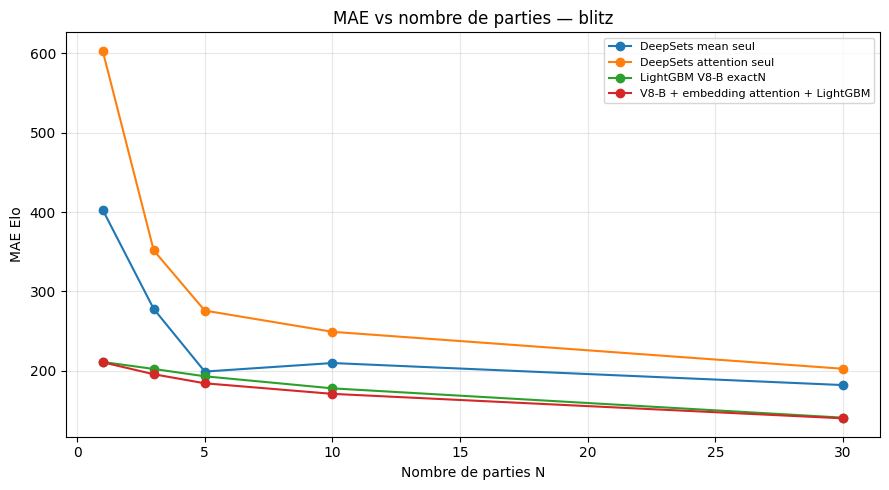

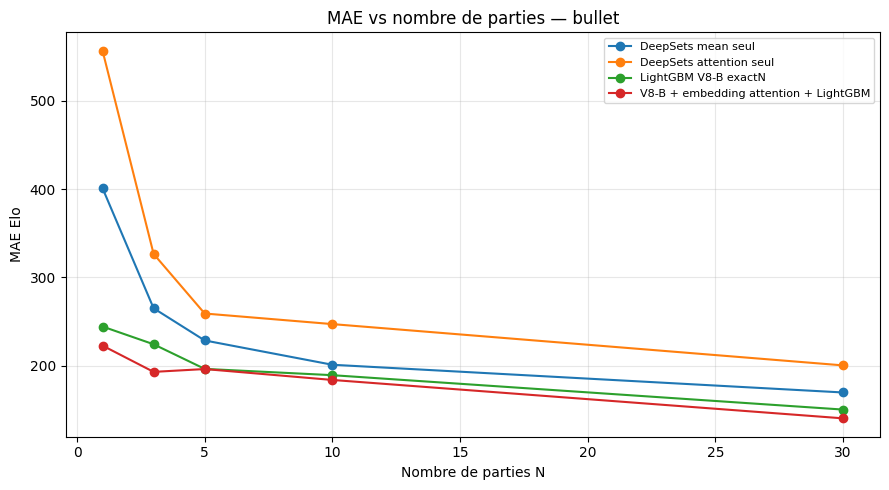

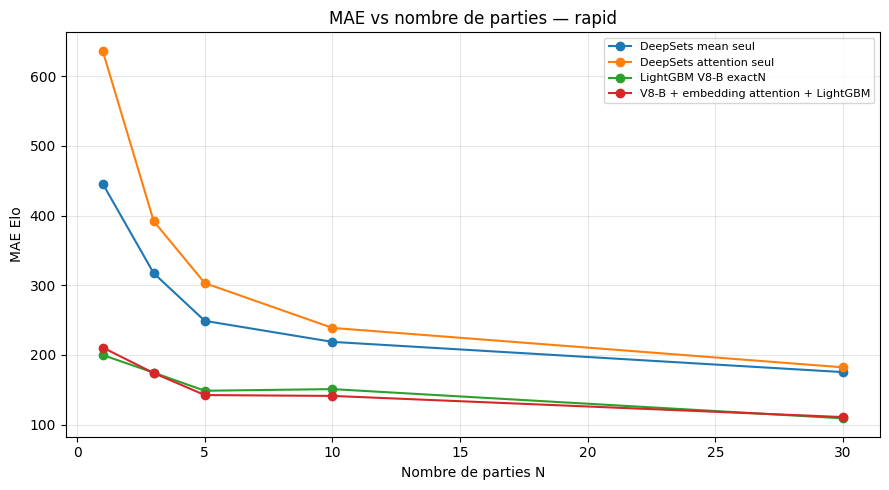

In [20]:
# ============================================================
# 9. Résultats synthétiques
# ============================================================

summary = results_df.sort_values(['cadence', 'N', 'MAE']).copy()
display(summary)

print('\nMeilleur modèle par cadence et N :')
best = summary.groupby(['cadence', 'N']).first().reset_index()
display(best[['cadence', 'N', 'approach', 'MAE', 'R2', 'n_features']])

# Courbes MAE vs N
for cadence in sorted(results_df['cadence'].unique()):
    sub = results_df[results_df['cadence'] == cadence]
    plt.figure(figsize=(9, 5))
    for approach in sub['approach'].unique():
        s = sub[sub['approach'] == approach].sort_values('N')
        plt.plot(s['N'], s['MAE'], marker='o', label=approach)
    plt.title(f'MAE vs nombre de parties — {cadence}')
    plt.xlabel('Nombre de parties N')
    plt.ylabel('MAE Elo')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 7. Visualisation simple des poids d'attention

Cette cellule affiche les poids d'attention pour quelques joueurs de test à N=10.  
Un poids élevé signifie que le modèle a davantage utilisé cette partie dans l'embedding joueur.

Attention : ce n'est pas une explication causale parfaite, seulement un indice sur les parties utilisées par le modèle.



BULLET — exemples de poids attention, N=10
Joueur exemple 1: [0.008 0.09  0.171 0.026 0.106 0.171 0.145 0.094 0.02  0.171] somme= 1.0


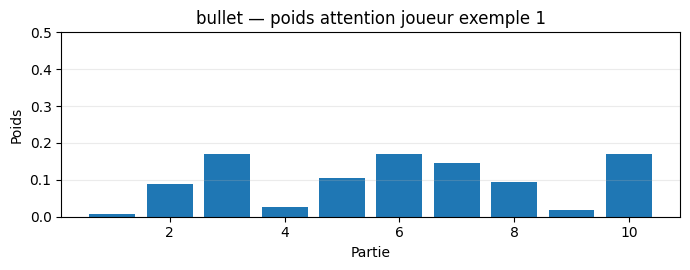

Joueur exemple 2: [0.117 0.031 0.124 0.202 0.032 0.1   0.122 0.199 0.073 0.001] somme= 1.0


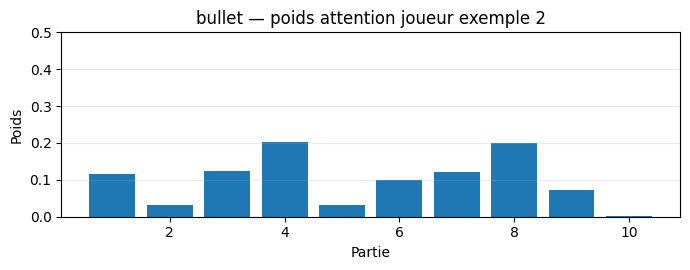

Joueur exemple 3: [0.004 0.107 0.215 0.131 0.124 0.215 0.003 0.005 0.064 0.132] somme= 1.0


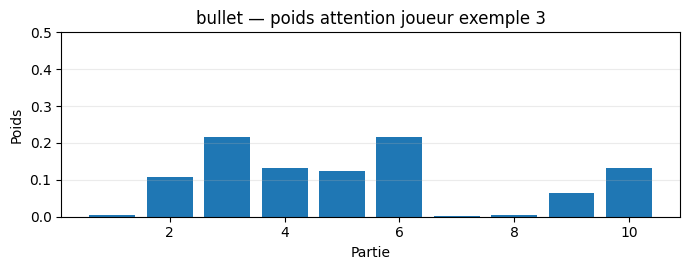


BLITZ — exemples de poids attention, N=10
Joueur exemple 1: [0.101 0.09  0.101 0.229 0.102 0.116 0.103 0.102 0.029 0.025] somme= 1.0


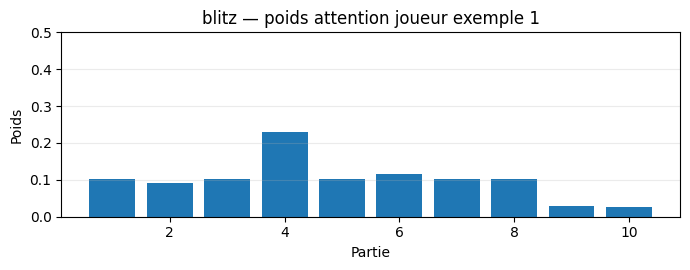

Joueur exemple 2: [0.002 0.109 0.01  0.233 0.109 0.109 0.109 0.    0.228 0.091] somme= 1.0


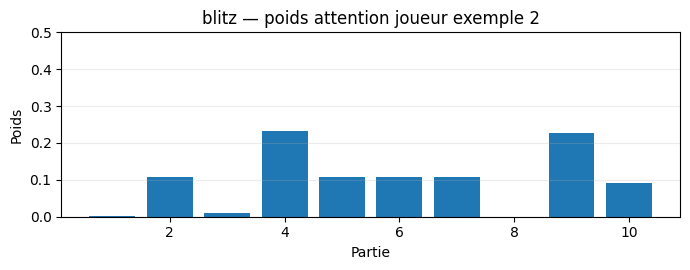

Joueur exemple 3: [0.074 0.161 0.159 0.013 0.039 0.074 0.074 0.165 0.075 0.166] somme= 1.0


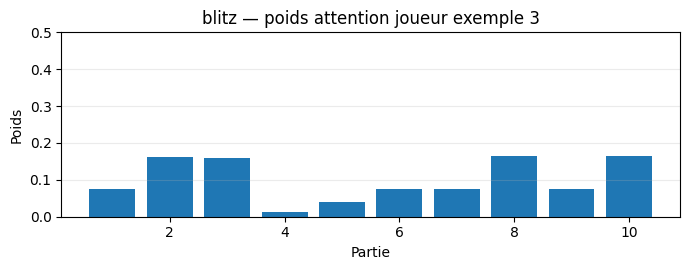


RAPID — exemples de poids attention, N=10
Joueur exemple 1: [0.023 0.127 0.038 0.127 0.032 0.13  0.032 0.191 0.109 0.191] somme= 1.0


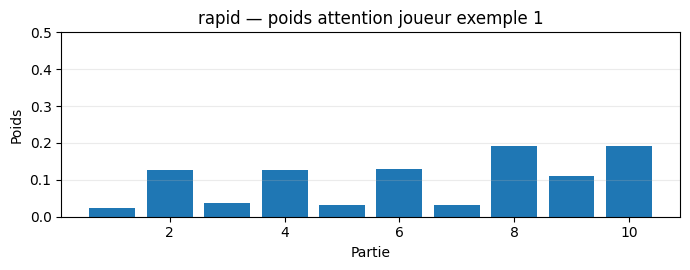

Joueur exemple 2: [0.224 0.121 0.1   0.001 0.152 0.222 0.01  0.051 0.077 0.044] somme= 1.0


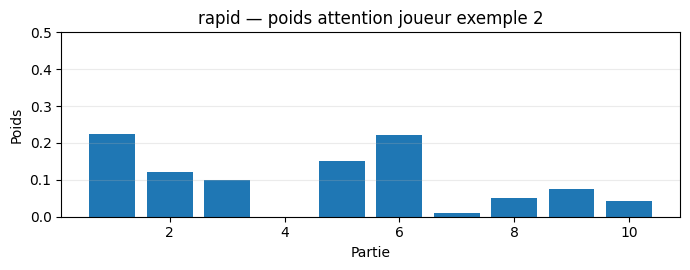

Joueur exemple 3: [0.142 0.097 0.096 0.121 0.097 0.077 0.097 0.051 0.079 0.142] somme= 1.0


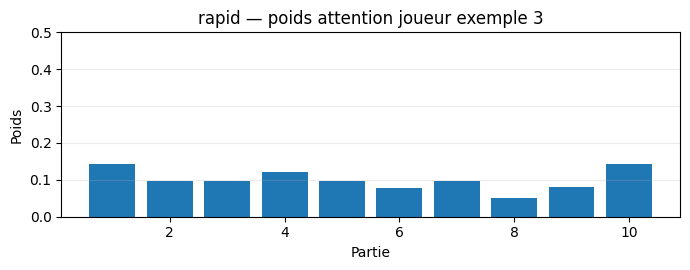

In [21]:
# ============================================================
# 10. Visualisation poids d'attention pour quelques exemples
# ============================================================

for cadence, weights in attention_weights_examples.items():
    if weights is None:
        continue
    print(f'\n{cadence.upper()} — exemples de poids attention, N=10')
    for i, w in enumerate(weights[:3]):
        valid = w[:10]
        print(f'Joueur exemple {i+1}:', np.round(valid, 3), 'somme=', round(valid.sum(), 3))
        plt.figure(figsize=(7, 2.8))
        plt.bar(np.arange(1, 11), valid)
        plt.title(f'{cadence} — poids attention joueur exemple {i+1}')
        plt.xlabel('Partie')
        plt.ylabel('Poids')
        plt.ylim(0, max(0.5, valid.max() + 0.05))
        plt.grid(True, axis='y', alpha=0.25)
        plt.tight_layout()
        plt.show()


## 8. Comment lire les résultats

À regarder en priorité :

1. **LightGBM V8 exactN** : baseline forte issue de vos anciens notebooks.
2. **DeepSets mean seul** : baseline neuronale propre, invariant à l'ordre des parties.
3. **DeepSets attention seul** : même principe, mais avec pondération apprise des parties.
4. **V8 + embedding attention + LightGBM** : variante probablement la plus prometteuse.

Si l'hybride améliore la MAE pour `N=3`, `N=5` ou `N=10`, c'est un résultat très intéressant : cela signifie que l'embedding neuronal ajoute une information utile aux features V8.

Si le neural seul ne bat pas LightGBM, ce n'est pas grave : avec 500–700 joueurs par cadence, LightGBM reste naturellement très fort sur tabulaire.


In [22]:
# ============================================================
# 11. Expérience complémentaire ciblée : hybrides utiles seulement
# ============================================================

# Objectif :
# - ne plus tester les modèles neuronaux seuls, car ils étaient faibles ;
# - tester uniquement les variantes prometteuses :
#   1) LightGBM V8 exact-N
#   2) V8 + embedding mean + LightGBM
#   3) V8 + embedding attention + LightGBM
# - répéter sur plusieurs seeds pour vérifier la stabilité.

FOCUSED_N_VALUES = [3, 5, 10, 30]
FOCUSED_SEEDS = [0, 1, 2]

focused_results = []
focused_models = {}

print("N testés :", FOCUSED_N_VALUES)
print("Seeds testées :", FOCUSED_SEEDS)

# Sécurité : vérifier que les variables principales existent
required_vars = [
    "cadence_data", "GAME_FEATURE_COLS", "neural_models",
    "PlayerSetDataset", "predict_and_embed",
    "build_player_dataset_exact_n", "fit_eval_lgbm", "merge_embeddings"
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Variables/fonctions manquantes : {missing}. Exécute d'abord les cellules précédentes du notebook.")

print("✓ Variables nécessaires disponibles.")

N testés : [3, 5, 10, 30]
Seeds testées : [0, 1, 2]
✓ Variables nécessaires disponibles.


In [23]:
# ============================================================
# 12. Fonction : évaluer V8 vs hybrides embeddings sur un N et une seed
# ============================================================

def evaluate_focused_hybrids_for_one_setting(
    cadence: str,
    N: int,
    seed: int,
    use_mean_embedding: bool = True,
    use_attention_embedding: bool = True,
):
    """
    Évalue pour une cadence, un N et une seed :
    - LightGBM V8-B exact-N
    - V8 + embedding mean + LightGBM
    - V8 + embedding attention + LightGBM

    Important :
    Pour N=5, les features V8 et les embeddings sont calculés avec les mêmes N parties.
    Donc pas de leakage depuis les 30 parties.
    """

    obj = cadence_data[cadence]
    df_c = obj["df"]
    train_players = obj["train_players"]
    val_players = obj["val_players"]
    test_players = obj["test_players"]

    train_val_players = np.concatenate([train_players, val_players])

    # On récupère les modèles déjà entraînés dans la première expérience.
    mean_model = neural_models[cadence].get("mean", None)
    att_model = neural_models[cadence].get("attention", None)
    transform_wrapper = neural_models[cadence]["scaler"]

    # --------------------------------------------------------
    # 1. Construire les features V8 exact-N
    # --------------------------------------------------------
    player_train = build_player_dataset_exact_n(
        df_c, train_val_players, N, seed=seed
    )
    player_test = build_player_dataset_exact_n(
        df_c, test_players, N, seed=seed
    )

    # --------------------------------------------------------
    # 2. Baseline LightGBM V8-B exact-N
    # --------------------------------------------------------
    res_v8 = fit_eval_lgbm(
        player_train,
        player_test,
        target="elo",
        random_state=seed,
        cadence=cadence
    )

    rows = []

    rows.append({
        "cadence": cadence,
        "N": N,
        "seed": seed,
        "approach": V8_BASELINE_LABEL,
        "MAE": res_v8["MAE"],
        "RMSE": res_v8["RMSE"],
        "R2": res_v8["R2"],
        "n_features": res_v8["n_features"],
    })

    focused_models[(cadence, N, seed, V8_BASELINE_LABEL)] = res_v8

    # Datasets fixed-N pour extraire les embeddings avec exactement N parties
    trv_ds_fixed = PlayerSetDataset(
        df_c,
        train_val_players,
        GAME_FEATURE_COLS,
        max_n=MAX_N,
        fixed_n=N,
        seed=seed,
        scaler=transform_wrapper
    )

    te_ds_fixed = PlayerSetDataset(
        df_c,
        test_players,
        GAME_FEATURE_COLS,
        max_n=MAX_N,
        fixed_n=N,
        seed=seed,
        scaler=transform_wrapper
    )

    trv_loader_fixed = DataLoader(
        trv_ds_fixed,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    te_loader_fixed = DataLoader(
        te_ds_fixed,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # --------------------------------------------------------
    # 3. Hybride avec embedding mean
    # --------------------------------------------------------
    if use_mean_embedding and mean_model is not None:
        mean_emb_train, _ = predict_and_embed(mean_model, trv_loader_fixed)
        mean_emb_test, _ = predict_and_embed(mean_model, te_loader_fixed)

        hybrid_mean_train = merge_embeddings(player_train, mean_emb_train)
        hybrid_mean_test = merge_embeddings(player_test, mean_emb_test)

        res_hyb_mean = fit_eval_lgbm(
            hybrid_mean_train,
            hybrid_mean_test,
            target="elo",
            random_state=seed,
            cadence=cadence
        )

        rows.append({
            "cadence": cadence,
            "N": N,
            "seed": seed,
            "approach": f"{V8_HYBRID_PREFIX} + embedding mean + LightGBM",
            "MAE": res_hyb_mean["MAE"],
            "RMSE": res_hyb_mean["RMSE"],
            "R2": res_hyb_mean["R2"],
            "n_features": res_hyb_mean["n_features"],
        })

        focused_models[(cadence, N, seed, f"{V8_HYBRID_PREFIX} + embedding mean + LightGBM")] = res_hyb_mean

    # --------------------------------------------------------
    # 4. Hybride avec embedding attention
    # --------------------------------------------------------
    if use_attention_embedding and att_model is not None:
        att_emb_train, _ = predict_and_embed(att_model, trv_loader_fixed)
        att_emb_test, _ = predict_and_embed(att_model, te_loader_fixed)

        hybrid_att_train = merge_embeddings(player_train, att_emb_train)
        hybrid_att_test = merge_embeddings(player_test, att_emb_test)

        res_hyb_att = fit_eval_lgbm(
            hybrid_att_train,
            hybrid_att_test,
            target="elo",
            random_state=seed,
            cadence=cadence
        )

        rows.append({
            "cadence": cadence,
            "N": N,
            "seed": seed,
            "approach": f"{V8_HYBRID_PREFIX} + embedding attention + LightGBM",
            "MAE": res_hyb_att["MAE"],
            "RMSE": res_hyb_att["RMSE"],
            "R2": res_hyb_att["R2"],
            "n_features": res_hyb_att["n_features"],
        })

        focused_models[(cadence, N, seed, f"{V8_HYBRID_PREFIX} + embedding attention + LightGBM")] = res_hyb_att

    return rows

In [24]:
# ============================================================
# 13. Lancement expérience ciblée multi-seed
# ============================================================

focused_results = []
focused_models = {}

for cadence in cadence_data.keys():
    print("\n" + "=" * 90)
    print(f"CADENCE : {cadence.upper()}")
    print("=" * 90)

    for N in FOCUSED_N_VALUES:
        for seed in FOCUSED_SEEDS:
            print(f"\n--- cadence={cadence} | N={N} | seed={seed} ---")

            rows = evaluate_focused_hybrids_for_one_setting(
                cadence=cadence,
                N=N,
                seed=seed,
                use_mean_embedding=True,
                use_attention_embedding=True,
            )

            focused_results.extend(rows)

            # Affichage court
            tmp = pd.DataFrame(rows).sort_values("MAE")
            display(tmp[["cadence", "N", "seed", "approach", "MAE", "R2", "n_features"]])

focused_results_df = pd.DataFrame(focused_results)

print("\n✓ Expérience ciblée terminée.")
display(focused_results_df.head())


CADENCE : BULLET

--- cadence=bullet | N=3 | seed=0 ---
✓ player_features V8 : 560 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features


,cadence,N,seed,approach,MAE,R2,n_features
2,bullet,3,0,V8-B + embedding attention + LightGBM,216.820,0.272,185
1,bullet,3,0,V8-B + embedding mean + LightGBM,218.692,0.337,185
0,bullet,3,0,LightGBM V8-B exactN,224.730,0.262,137



--- cadence=bullet | N=3 | seed=1 ---
✓ player_features V8 : 560 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features


,cadence,N,seed,approach,MAE,R2,n_features
1,bullet,3,1,V8-B + embedding mean + LightGBM,195.448,0.451,185
2,bullet,3,1,V8-B + embedding attention + LightGBM,196.152,0.430,185
0,bullet,3,1,LightGBM V8-B exactN,213.581,0.361,137



--- cadence=bullet | N=3 | seed=2 ---
✓ player_features V8 : 560 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features


...

,cadence,N,seed,approach,MAE,R2,n_features
1,rapid,30,1,V8-B + embedding mean + LightGBM,108.517,0.715,151
2,rapid,30,1,V8-B + embedding attention + LightGBM,109.337,0.714,151
0,rapid,30,1,LightGBM V8-B exactN,109.907,0.702,103



--- cadence=rapid | N=30 | seed=2 ---
✓ player_features V8 : 388 joueurs × 216 features
✓ player_features V8 : 98 joueurs × 216 features


,cadence,N,seed,approach,MAE,R2,n_features
2,rapid,30,2,V8-B + embedding attention + LightGBM,108.427,0.726,151
1,rapid,30,2,V8-B + embedding mean + LightGBM,110.116,0.713,151
0,rapid,30,2,LightGBM V8-B exactN,111.659,0.697,103



✓ Expérience ciblée terminée.


,cadence,N,seed,approach,MAE,RMSE,R2,n_features
0,bullet,3,0,LightGBM V8-B exactN,224.730,280.147,0.262,137
1,bullet,3,0,V8-B + embedding mean + LightGBM,218.692,265.674,0.337,185
2,bullet,3,0,V8-B + embedding attention + LightGBM,216.820,278.346,0.272,185
3,bullet,3,1,LightGBM V8-B exactN,213.581,260.768,0.361,137
4,bullet,3,1,V8-B + embedding mean + LightGBM,195.448,241.693,0.451,185


In [25]:
# ============================================================
# 14. Résumé : moyenne ± std sur les seeds
# ============================================================

focused_summary = (
    focused_results_df
    .groupby(["cadence", "N", "approach"])
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        n_runs=("seed", "count"),
        n_features=("n_features", "mean"),
    )
    .reset_index()
    .sort_values(["cadence", "N", "MAE_mean"])
)

focused_summary["MAE_display"] = (
    focused_summary["MAE_mean"].round(1).astype(str)
    + " ± "
    + focused_summary["MAE_std"].round(1).astype(str)
)

display(focused_summary)

print("\nMeilleur modèle moyen par cadence et N :")
focused_best = (
    focused_summary
    .sort_values(["cadence", "N", "MAE_mean"])
    .groupby(["cadence", "N"])
    .first()
    .reset_index()
)

display(focused_best[[
    "cadence", "N", "approach", "MAE_display", "R2_mean", "n_runs"
]])

,cadence,N,approach,MAE_mean,MAE_std,RMSE_mean,R2_mean,n_runs,n_features,MAE_display
1,blitz,3,V8-B + embedding attention + LightGBM,191.450,8.546,235.828,0.406,3,159.000,191.5 ± 8.5
2,blitz,3,V8-B + embedding mean + LightGBM,192.272,9.390,236.218,0.404,3,159.000,192.3 ± 9.4
0,blitz,3,LightGBM V8-B exactN,202.548,8.908,246.144,0.353,3,111.000,202.5 ± 8.9
5,blitz,5,V8-B + embedding mean + LightGBM,174.660,7.118,219.000,0.488,3,159.000,174.7 ± 7.1
4,blitz,5,V8-B + embedding attention + LightGBM,180.855,5.303,220.332,0.482,3,159.000,180.9 ± 5.3
3,blitz,5,LightGBM V8-B exactN,191.426,1.721,233.532,0.418,3,111.000,191.4 ± 1.7
8,blitz,10,V8-B + embedding mean + LightGBM,159.718,4.701,197.815,0.583,3,159.000,159.7 ± 4.7
7,blitz,10,V8-B + embedding attention + LightGBM,164.971,3.176,203.778,0.557,3,159.000,165.0 ± 3.2
6,blitz,10,LightGBM V8-B exactN,166.766,3.959,207.854,0.539,3,111.000,166.8 ± 4.0
11,blitz,30,V8-B + embedding mean + LightGBM,135.702,3.007,173.234,0.680,3,159.000,135.7 ± 3.0



Meilleur modèle moyen par cadence et N :


,cadence,N,approach,MAE_display,R2_mean,n_runs
0,blitz,3,V8-B + embedding attention + LightGBM,191.5 ± 8.5,0.406,3
1,blitz,5,V8-B + embedding mean + LightGBM,174.7 ± 7.1,0.488,3
2,blitz,10,V8-B + embedding mean + LightGBM,159.7 ± 4.7,0.583,3
3,blitz,30,V8-B + embedding mean + LightGBM,135.7 ± 3.0,0.680,3
4,bullet,3,V8-B + embedding mean + LightGBM,204.9 ± 12.2,0.392,3
5,bullet,5,V8-B + embedding mean + LightGBM,184.1 ± 6.3,0.496,3
6,bullet,10,V8-B + embedding mean + LightGBM,174.3 ± 7.6,0.551,3
7,bullet,30,V8-B + embedding mean + LightGBM,129.2 ± 0.8,0.736,3
8,rapid,3,V8-B + embedding attention + LightGBM,160.7 ± 2.9,0.415,3
9,rapid,5,V8-B + embedding attention + LightGBM,164.4 ± 5.9,0.430,3


In [26]:
# ============================================================
# 15. Gains des hybrides par rapport à LightGBM V8
# ============================================================

baseline = focused_summary[
    focused_summary["approach"] == "LightGBM V8 exactN"
][["cadence", "N", "MAE_mean"]].rename(
    columns={"MAE_mean": "MAE_V8"}
)

gain_table = focused_summary.merge(
    baseline,
    on=["cadence", "N"],
    how="left"
)

gain_table["gain_vs_V8"] = gain_table["MAE_V8"] - gain_table["MAE_mean"]

gain_table = gain_table.sort_values(
    ["cadence", "N", "MAE_mean"]
)

display(gain_table[[
    "cadence",
    "N",
    "approach",
    "MAE_display",
    "MAE_V8",
    "gain_vs_V8",
    "R2_mean",
    "n_runs"
]])

print("""
Lecture :
gain_vs_V8 > 0  => le modèle améliore LightGBM V8.
gain_vs_V8 < 0  => le modèle est moins bon que LightGBM V8.
""")

,cadence,N,approach,MAE_display,MAE_V8,gain_vs_V8,R2_mean,n_runs
0,blitz,3,V8-B + embedding attention + LightGBM,191.5 ± 8.5,NaN,NaN,0.406,3
1,blitz,3,V8-B + embedding mean + LightGBM,192.3 ± 9.4,NaN,NaN,0.404,3
2,blitz,3,LightGBM V8-B exactN,202.5 ± 8.9,NaN,NaN,0.353,3
3,blitz,5,V8-B + embedding mean + LightGBM,174.7 ± 7.1,NaN,NaN,0.488,3
4,blitz,5,V8-B + embedding attention + LightGBM,180.9 ± 5.3,NaN,NaN,0.482,3
5,blitz,5,LightGBM V8-B exactN,191.4 ± 1.7,NaN,NaN,0.418,3
6,blitz,10,V8-B + embedding mean + LightGBM,159.7 ± 4.7,NaN,NaN,0.583,3
7,blitz,10,V8-B + embedding attention + LightGBM,165.0 ± 3.2,NaN,NaN,0.557,3
8,blitz,10,LightGBM V8-B exactN,166.8 ± 4.0,NaN,NaN,0.539,3
9,blitz,30,V8-B + embedding mean + LightGBM,135.7 ± 3.0,NaN,NaN,0.680,3



Lecture :
gain_vs_V8 > 0  => le modèle améliore LightGBM V8.
gain_vs_V8 < 0  => le modèle est moins bon que LightGBM V8.



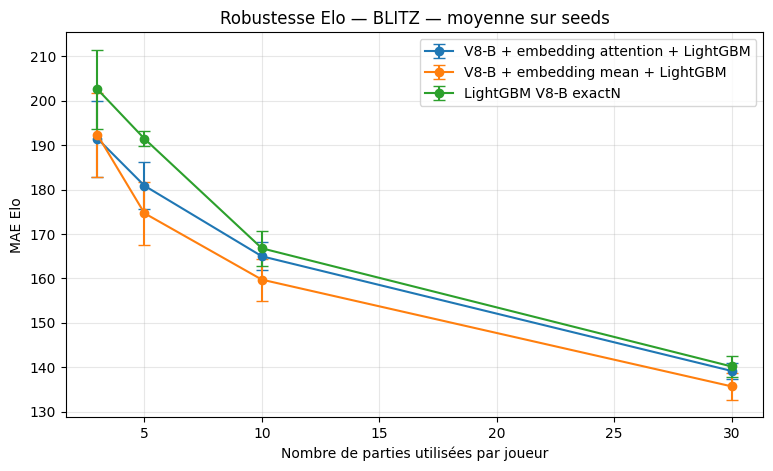

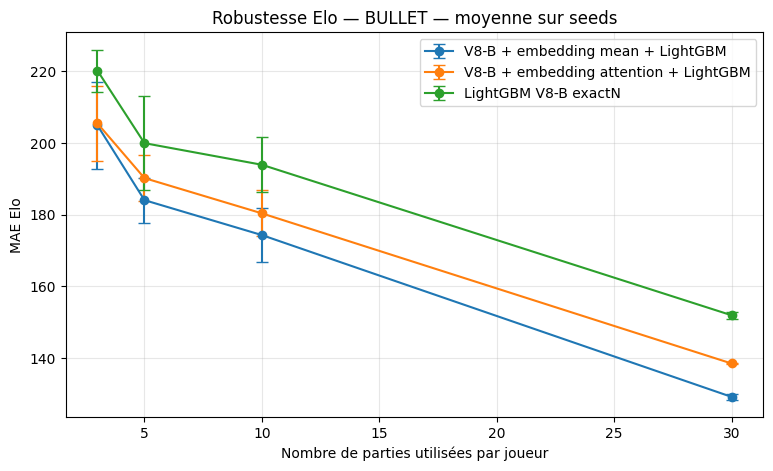

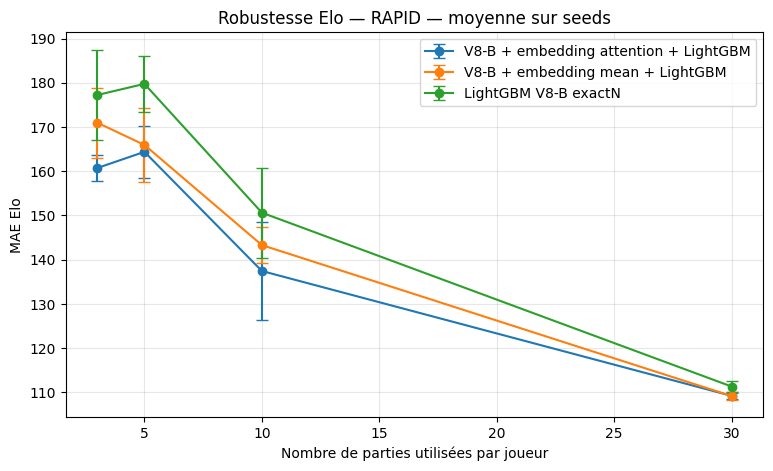

In [27]:
# ============================================================
# 16. Courbes MAE vs N avec barres d'erreur
# ============================================================

for cadence in focused_summary["cadence"].unique():
    sub = focused_summary[focused_summary["cadence"] == cadence].copy()

    plt.figure(figsize=(9, 5))

    for approach in sub["approach"].unique():
        s = sub[sub["approach"] == approach].sort_values("N")

        plt.errorbar(
            s["N"],
            s["MAE_mean"],
            yerr=s["MAE_std"],
            marker="o",
            capsize=4,
            label=approach
        )

    plt.title(f"Robustesse Elo — {cadence.upper()} — moyenne sur seeds")
    plt.xlabel("Nombre de parties utilisées par joueur")
    plt.ylabel("MAE Elo")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [28]:
# ============================================================
# 17. Analyse : est-ce que LightGBM utilise vraiment les embeddings ?
# ============================================================

def show_feature_importance_for_setting(cadence, N, seed, approach, top_k=30):
    key = (cadence, N, seed, approach)
    if key not in focused_models:
        print(f"Modèle absent : {key}")
        return None

    res = focused_models[key]
    model = res["model"]
    feature_cols = res["feature_cols"]

    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_df["is_embedding"] = imp_df["feature"].str.startswith("emb_")

    print(f"\n{cadence.upper()} | N={N} | seed={seed} | {approach}")
    print(f"MAE = {res['MAE']:.2f}")
    print(f"Embeddings dans top {top_k} :", int(imp_df.head(top_k)["is_embedding"].sum()))

    display(imp_df.head(top_k))

    return imp_df


# On analyse automatiquement le meilleur hybride moyen pour chaque cadence.
for cadence in focused_best["cadence"].unique():
    sub = focused_best[
        (focused_best["cadence"] == cadence)
        & (focused_best["approach"].str.contains("embedding"))
    ]

    if len(sub) == 0:
        print(f"Aucun hybride gagnant pour {cadence}.")
        continue

    row = sub.sort_values("MAE_mean").iloc[0]
    best_N = int(row["N"])
    best_approach = row["approach"]

    # On prend seed=0 pour inspecter un modèle concret.
    show_feature_importance_for_setting(
        cadence=cadence,
        N=best_N,
        seed=FOCUSED_SEEDS[0],
        approach=best_approach,
        top_k=30
    )


BLITZ | N=30 | seed=0 | V8-B + embedding mean + LightGBM
MAE = 136.72
Embeddings dans top 30 : 0


,feature,importance,is_embedding
98,loss_when_losing_mean,136,False
41,time_middlegame_mean_s_iqr,112,False
40,time_opening_median_s_iqr,112,False
69,n_moves_winning_mean,101,False
34,time_median_s_iqr,90,False
83,loss_log_mean_std,88,False
90,n_errors_std,85,False
29,rate_blunder_when_winning_smooth_mean,81,False
76,n_moves_opening_mean,79,False
103,rate_capture_mean,71,False



BULLET | N=30 | seed=0 | V8-B + embedding mean + LightGBM
MAE = 128.28
Embeddings dans top 30 : 2


,feature,importance,is_embedding
132,win_rate,113,False
126,rate_check_mean,88,False
125,rate_capture_mean,79,False
119,time_log_mean_std,78,False
140,emb_03,75,True
99,rate_inaccuracy_mean,65,False
69,loss_per_second_iqr,64,False
94,loss_std_std,64,False
40,time_median_s_iqr,61,False
120,clock_mean_s_std,61,False



RAPID | N=30 | seed=0 | V8-B + embedding mean + LightGBM
MAE = 108.89
Embeddings dans top 30 : 0


,feature,importance,is_embedding
12,loss_endgame_mean_mean,86,False
76,n_moves_opening_mean,84,False
80,loss_max_std,83,False
82,loss_log_mean_std,79,False
90,loss_when_losing_std,77,False
43,time_opening_median_s_iqr,74,False
0,loss_mean_iqr_x,71,False
29,rate_blunder_when_winning_smooth_mean,69,False
21,rate_blunder_middlegame_smooth_median,65,False
73,n_moves_equal_median,62,False


In [29]:
# ============================================================
# 18. Comparaison directe : mean embedding vs attention embedding
# ============================================================

emb_compare = focused_summary[
    focused_summary["approach"].isin([
        "V8 + embedding mean + LightGBM",
        "V8 + embedding attention + LightGBM"
    ])
].copy()

pivot_emb = emb_compare.pivot_table(
    index=["cadence", "N"],
    columns="approach",
    values="MAE_mean"
).reset_index()

if {
    "V8 + embedding mean + LightGBM",
    "V8 + embedding attention + LightGBM"
}.issubset(set(pivot_emb.columns)):
    pivot_emb["attention_minus_mean"] = (
        pivot_emb["V8 + embedding attention + LightGBM"]
        - pivot_emb["V8 + embedding mean + LightGBM"]
    )

    display(pivot_emb)

    print("""
Lecture :
attention_minus_mean < 0  => attention meilleure que mean.
attention_minus_mean > 0  => mean meilleure que attention.
""")
else:
    print("Les deux variantes mean et attention ne sont pas présentes dans les résultats.")

Les deux variantes mean et attention ne sont pas présentes dans les résultats.


In [30]:
# ============================================================
# 20. Choix final : meilleur compromis dans le régime faible N
# ============================================================

# Objectif :
# On veut choisir un nombre de parties réaliste pour un système adaptatif.
# Donc N=30 sert de référence haute, mais n'est PAS candidat au choix final.
#
# On choisit parmi les petits N, par défaut N <= 10.
#
# Règle :
# 1. Pour chaque cadence et chaque N, on garde le meilleur modèle.
# 2. On garde seulement les N <= MAX_FINAL_N.
# 3. On choisit le plus petit N dont la MAE est proche du meilleur petit-N.
# 4. Si N=5 est presque aussi bon que N=10, on choisit N=5.
# 5. Si N=3 est presque aussi bon que N=5 ou N=10, on choisit N=3.

MAX_FINAL_N = 10          # N=30 est exclu du choix final
TOLERANCE_SMALL_N = 10.0  # marge Elo acceptée pour préférer un N plus petit

MODEL_PRIORITY = {
    "V8 + embedding mean + LightGBM": 0,
    "V8 + embedding attention + LightGBM": 1,
    "LightGBM V8 exactN": 2,
}


def choose_best_low_N_tradeoff(summary_df, cadence, max_final_n=10, tolerance_elo=10.0):
    """
    Choisit le meilleur compromis en se limitant aux petits N.

    N=30 est utilisé comme référence, mais pas comme candidat final.
    """

    sub = summary_df[summary_df["cadence"] == cadence].copy()

    if sub.empty:
        raise ValueError(f"Aucun résultat pour cadence={cadence}")

    sub["model_priority"] = sub["approach"].map(MODEL_PRIORITY).fillna(99)

    # Meilleur modèle pour chaque N
    best_by_N = (
        sub.sort_values(
            by=["N", "MAE_mean", "MAE_std", "model_priority"],
            ascending=[True, True, True, True]
        )
        .groupby("N")
        .first()
        .reset_index()
        .sort_values("N")
    )

    # Référence brute, y compris N=30
    raw_best = best_by_N.sort_values("MAE_mean").iloc[0]

    # Candidats finaux : uniquement petits N
    low_N_candidates = best_by_N[best_by_N["N"] <= max_final_n].copy()

    if low_N_candidates.empty:
        raise ValueError(
            f"Aucun N <= {max_final_n} disponible pour cadence={cadence}"
        )

    # Meilleur score dans la zone faible N
    best_low_mae = low_N_candidates["MAE_mean"].min()

    # On accepte les modèles proches du meilleur faible-N
    acceptable = low_N_candidates[
        low_N_candidates["MAE_mean"] <= best_low_mae + tolerance_elo
    ].copy()

    # Parmi les acceptables, on choisit le plus petit N.
    # Si plusieurs modèles au même N, on choisit le meilleur modèle.
    chosen = (
        acceptable
        .sort_values(
            by=["N", "MAE_mean", "MAE_std", "model_priority"],
            ascending=[True, True, True, True]
        )
        .iloc[0]
    )

    # Meilleur petit-N brut
    low_N_best = low_N_candidates.sort_values("MAE_mean").iloc[0]

    return {
        "cadence": cadence,

        "chosen_N": int(chosen["N"]),
        "chosen_approach": chosen["approach"],
        "chosen_MAE_mean": chosen["MAE_mean"],
        "chosen_MAE_std": chosen["MAE_std"],
        "chosen_R2_mean": chosen["R2_mean"],

        "best_low_N": int(low_N_best["N"]),
        "best_low_approach": low_N_best["approach"],
        "best_low_MAE_mean": low_N_best["MAE_mean"],
        "best_low_MAE_std": low_N_best["MAE_std"],

        "raw_best_N": int(raw_best["N"]),
        "raw_best_approach": raw_best["approach"],
        "raw_best_MAE_mean": raw_best["MAE_mean"],
        "raw_best_MAE_std": raw_best["MAE_std"],

        "delta_vs_best_low_N": chosen["MAE_mean"] - low_N_best["MAE_mean"],
        "delta_vs_raw_best": chosen["MAE_mean"] - raw_best["MAE_mean"],

        "max_final_N": max_final_n,
        "tolerance_small_N": tolerance_elo,
    }, best_by_N


final_choices = []
curves_by_cadence = {}

for cadence in focused_summary["cadence"].unique():
    choice, curve = choose_best_low_N_tradeoff(
        focused_summary,
        cadence,
        max_final_n=MAX_FINAL_N,
        tolerance_elo=TOLERANCE_SMALL_N
    )
    final_choices.append(choice)
    curves_by_cadence[cadence] = curve

final_choices_df = pd.DataFrame(final_choices)

final_choices_df["chosen_MAE_display"] = (
    final_choices_df["chosen_MAE_mean"].round(1).astype(str)
    + " ± "
    + final_choices_df["chosen_MAE_std"].round(1).astype(str)
)

final_choices_df["best_low_MAE_display"] = (
    final_choices_df["best_low_MAE_mean"].round(1).astype(str)
    + " ± "
    + final_choices_df["best_low_MAE_std"].round(1).astype(str)
)

final_choices_df["raw_best_MAE_display"] = (
    final_choices_df["raw_best_MAE_mean"].round(1).astype(str)
    + " ± "
    + final_choices_df["raw_best_MAE_std"].round(1).astype(str)
)

display(final_choices_df[[
    "cadence",
    "chosen_N",
    "chosen_approach",
    "chosen_MAE_display",
    "best_low_N",
    "best_low_approach",
    "best_low_MAE_display",
    "raw_best_N",
    "raw_best_approach",
    "raw_best_MAE_display",
    "delta_vs_best_low_N",
    "delta_vs_raw_best",
    "max_final_N",
    "tolerance_small_N",
]])

print("""
Lecture :
- chosen_N : choix recommandé pour un système qui doit fonctionner avec peu de parties.
- best_low_N : meilleur score parmi les petits N seulement.
- raw_best_N : meilleur score absolu, souvent N=30.
- delta_vs_best_low_N : perte acceptée pour choisir moins de parties.
- delta_vs_raw_best : coût par rapport au meilleur score absolu.

Ici, N=30 est une référence haute, mais n'est pas candidat au choix final.
""")

,cadence,chosen_N,chosen_approach,chosen_MAE_display,best_low_N,best_low_approach,best_low_MAE_display,raw_best_N,raw_best_approach,raw_best_MAE_display,delta_vs_best_low_N,delta_vs_raw_best,max_final_N,tolerance_small_N
0,blitz,10,V8-B + embedding mean + LightGBM,159.7 ± 4.7,10,V8-B + embedding mean + LightGBM,159.7 ± 4.7,30,V8-B + embedding mean + LightGBM,135.7 ± 3.0,0.000,24.016,10,10.000
1,bullet,5,V8-B + embedding mean + LightGBM,184.1 ± 6.3,10,V8-B + embedding mean + LightGBM,174.3 ± 7.6,30,V8-B + embedding mean + LightGBM,129.2 ± 0.8,9.749,54.896,10,10.000
2,rapid,10,V8-B + embedding attention + LightGBM,137.4 ± 11.0,10,V8-B + embedding attention + LightGBM,137.4 ± 11.0,30,V8-B + embedding mean + LightGBM,109.2 ± 0.8,0.000,28.271,10,10.000



Lecture :
- chosen_N : choix recommandé pour un système qui doit fonctionner avec peu de parties.
- best_low_N : meilleur score parmi les petits N seulement.
- raw_best_N : meilleur score absolu, souvent N=30.
- delta_vs_best_low_N : perte acceptée pour choisir moins de parties.
- delta_vs_raw_best : coût par rapport au meilleur score absolu.

Ici, N=30 est une référence haute, mais n'est pas candidat au choix final.



In [31]:
# ============================================================
# 22. Configuration expérience incertitude / intervalles Elo
# ============================================================

# On va utiliser la méthode conformal prediction :
# - entraîner le modèle sur train_players ;
# - calibrer l'intervalle sur val_players ;
# - évaluer sur test_players.
#
# Avantage :
# C'est simple, robuste, et très défendable dans le rapport.

ALPHA = 0.20  # intervalle à environ 80%
# Pour un intervalle à 90%, utilisez ALPHA = 0.10

uncertainty_results = []
uncertainty_predictions = {}
uncertainty_models = {}

# Si final_choices_df existe, on récupère automatiquement les choix finaux.
# Sinon, on met une configuration manuelle d'après vos derniers résultats.
if "final_choices_df" in globals():
    FINAL_MODEL_CONFIGS = {}

    for _, row in final_choices_df.iterrows():
        FINAL_MODEL_CONFIGS[row["cadence"]] = {
            "N": int(row["chosen_N"]),
            "approach": row["chosen_approach"]
        }
else:
    FINAL_MODEL_CONFIGS = {
        "bullet": {
            "N": 5,
            "approach": f"{V8_HYBRID_PREFIX} + embedding mean + LightGBM"
        },
        "blitz": {
            "N": 10,
            "approach": f"{V8_HYBRID_PREFIX} + embedding mean + LightGBM"
        },
        "rapid": {
            "N": 10,
            "approach": f"{V8_HYBRID_PREFIX} + embedding attention + LightGBM"
        }
    }

print("Configurations finales utilisées :")
for cadence, cfg in FINAL_MODEL_CONFIGS.items():
    print(cadence, "→", cfg)

required_vars = [
    "cadence_data",
    "GAME_FEATURE_COLS",
    "neural_models",
    "PlayerSetDataset",
    "predict_and_embed",
    "build_player_dataset_exact_n",
    "merge_embeddings",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Variables/fonctions manquantes : {missing}")

print("\n✓ Variables nécessaires disponibles.")

Configurations finales utilisées :
blitz → {'N': 10, 'approach': 'V8-B + embedding mean + LightGBM'}
bullet → {'N': 5, 'approach': 'V8-B + embedding mean + LightGBM'}
rapid → {'N': 10, 'approach': 'V8-B + embedding attention + LightGBM'}

✓ Variables nécessaires disponibles.


In [32]:
# ============================================================
# 23. Fonctions utilitaires pour conformal prediction
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor


def get_lgbm_feature_columns(df, target="elo", cadence: str = None):
    """
    Sélectionne les colonnes numériques utilisables par LightGBM.
    Réutilise le même filtre V8-B que l'expérience principale si disponible.
    """
    if 'get_player_feature_cols_safe' in globals():
        return get_player_feature_cols_safe(df, cadence=cadence)

    exclude = {
        target,
        "player_id",
        "cadence",
        "game_id",
        "username",
        "name",
    }

    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)

    return cols


def fit_lgbm_basic(train_df, target="elo", random_state=0, cadence: str = None):
    """
    Entraîne LightGBM sur un dataframe déjà préparé.
    """
    feature_cols = get_lgbm_feature_columns(train_df, target=target, cadence=cadence)

    X_train = train_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_train = train_df[target].astype(float)

    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)

    return model, feature_cols


def predict_lgbm(model, feature_cols, df):
    """
    Prédit avec LightGBM sur un dataframe préparé.
    """
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return model.predict(X)


def conformal_interval_from_calibration(y_calib, pred_calib, alpha=0.20):
    """
    Calcule le rayon conformal q à partir des erreurs absolues sur calibration.

    Pour alpha=0.20, on vise environ 80% de couverture.
    """
    residuals = np.abs(np.asarray(y_calib) - np.asarray(pred_calib))

    # Quantile conformal simple
    q = np.quantile(residuals, 1 - alpha)

    return float(q), residuals


def evaluate_prediction_intervals(y_true, pred, q):
    """
    Évalue MAE, RMSE, R2, coverage et largeur d'intervalle.
    Version compatible avec les anciennes/nouvelles versions sklearn.
    """
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)

    lower = pred - q
    upper = pred + q

    covered = (y_true >= lower) & (y_true <= upper)
    coverage = covered.mean()
    width = np.mean(upper - lower)

    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2 = r2_score(y_true, pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "coverage": coverage,
        "avg_width": width,
        "q": q,
        "lower": lower,
        "upper": upper,
        "covered": covered
    }


In [33]:
# ============================================================
# 24. Construction des datasets pour incertitude
# ============================================================

def build_dataset_for_uncertainty(cadence, N, approach, seed=0):
    """
    Construit les datasets train / calibration / test pour une cadence et un N.

    Important :
    - train utilise train_players seulement ;
    - calibration utilise val_players seulement ;
    - test utilise test_players seulement.

    Cela permet de calibrer proprement les intervalles.
    """

    obj = cadence_data[cadence]

    df_c = obj["df"]
    train_players = obj["train_players"]
    val_players = obj["val_players"]
    test_players = obj["test_players"]

    # 1. Features V8 exact-N
    train_df = build_player_dataset_exact_n(
        df_c, train_players, N, seed=seed
    )

    calib_df = build_player_dataset_exact_n(
        df_c, val_players, N, seed=seed
    )

    test_df = build_player_dataset_exact_n(
        df_c, test_players, N, seed=seed
    )

    # 2. Si modèle hybride, on ajoute les embeddings exact-N
    if "embedding" in approach:
        if "mean" in approach:
            neural_kind = "mean"
        elif "attention" in approach:
            neural_kind = "attention"
        else:
            raise ValueError(f"Approche embedding inconnue : {approach}")

        neural_model = neural_models[cadence][neural_kind]
        transform_wrapper = neural_models[cadence]["scaler"]

        train_ds = PlayerSetDataset(
            df_c,
            train_players,
            GAME_FEATURE_COLS,
            max_n=MAX_N,
            fixed_n=N,
            seed=seed,
            scaler=transform_wrapper
        )

        calib_ds = PlayerSetDataset(
            df_c,
            val_players,
            GAME_FEATURE_COLS,
            max_n=MAX_N,
            fixed_n=N,
            seed=seed,
            scaler=transform_wrapper
        )

        test_ds = PlayerSetDataset(
            df_c,
            test_players,
            GAME_FEATURE_COLS,
            max_n=MAX_N,
            fixed_n=N,
            seed=seed,
            scaler=transform_wrapper
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        calib_loader = DataLoader(
            calib_ds,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        test_loader = DataLoader(
            test_ds,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        emb_train, _ = predict_and_embed(neural_model, train_loader)
        emb_calib, _ = predict_and_embed(neural_model, calib_loader)
        emb_test, _ = predict_and_embed(neural_model, test_loader)

        train_df = merge_embeddings(train_df, emb_train)
        calib_df = merge_embeddings(calib_df, emb_calib)
        test_df = merge_embeddings(test_df, emb_test)

    return train_df, calib_df, test_df

In [34]:
# ============================================================
# 25. Évaluation des intervalles sur les modèles finaux — VERSION CORRIGÉE
# ============================================================

# On évalue :
# - le modèle choisi final pour chaque cadence ;
# - et aussi LightGBM V8 seul au même N comme baseline d'incertitude.
#
# Corrections :
# - compatible avec l'absence de colonne player_id ;
# - utilise un dataframe de prédictions robuste ;
# - suppose que evaluate_prediction_intervals a déjà été corrigée pour RMSE.

UNCERTAINTY_SEEDS = [0, 1, 2]

uncertainty_results = []
uncertainty_predictions = {}
uncertainty_models = {}

for cadence, cfg in FINAL_MODEL_CONFIGS.items():
    N = cfg["N"]
    chosen_approach = cfg["approach"]

    approaches_to_test = [
        V8_BASELINE_LABEL,
        chosen_approach
    ]

    # éviter doublon si le modèle choisi est déjà LightGBM V8
    approaches_to_test = list(dict.fromkeys(approaches_to_test))

    print("\n" + "=" * 90)
    print(f"CADENCE : {cadence.upper()} | N={N}")
    print("=" * 90)

    for approach in approaches_to_test:
        for seed in UNCERTAINTY_SEEDS:
            print(f"\n--- approach={approach} | seed={seed} ---")

            train_df, calib_df, test_df = build_dataset_for_uncertainty(
                cadence=cadence,
                N=N,
                approach=approach,
                seed=seed
            )

            model, feature_cols = fit_lgbm_basic(
                train_df,
                target="elo",
                random_state=seed,
                cadence=cadence
            )

            pred_calib = predict_lgbm(model, feature_cols, calib_df)
            pred_test = predict_lgbm(model, feature_cols, test_df)

            y_calib = calib_df["elo"].astype(float).values
            y_test = test_df["elo"].astype(float).values

            q, calib_residuals = conformal_interval_from_calibration(
                y_calib,
                pred_calib,
                alpha=ALPHA
            )

            metrics = evaluate_prediction_intervals(
                y_true=y_test,
                pred=pred_test,
                q=q
            )

            row = {
                "cadence": cadence,
                "N": N,
                "approach": approach,
                "seed": seed,
                "alpha": ALPHA,
                "target_coverage": 1 - ALPHA,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "coverage": metrics["coverage"],
                "avg_width": metrics["avg_width"],
                "q": metrics["q"],
                "n_train": len(train_df),
                "n_calib": len(calib_df),
                "n_test": len(test_df),
                "n_features": len(feature_cols),
            }

            uncertainty_results.append(row)

            key = (cadence, N, approach, seed)

            uncertainty_models[key] = {
                "model": model,
                "feature_cols": feature_cols,
                "q": q,
                "calib_residuals": calib_residuals
            }

            # ------------------------------------------------------------
            # Construction robuste du dataframe de prédictions
            # ------------------------------------------------------------
            pred_df = pd.DataFrame(index=test_df.index).copy()

            if "player_id" in test_df.columns:
                pred_df["player_id"] = test_df["player_id"].values
            elif "target_username" in test_df.columns:
                pred_df["player_id"] = test_df["target_username"].values
            elif "username" in test_df.columns:
                pred_df["player_id"] = test_df["username"].values
            elif "player" in test_df.columns:
                pred_df["player_id"] = test_df["player"].values
            elif test_df.index.name is not None:
                pred_df["player_id"] = test_df.index.astype(str)
            else:
                pred_df["player_id"] = np.arange(len(test_df))

            pred_df["elo"] = test_df["elo"].astype(float).values
            pred_df["pred_elo"] = pred_test
            pred_df["lower"] = metrics["lower"]
            pred_df["upper"] = metrics["upper"]
            pred_df["covered"] = metrics["covered"]
            pred_df["interval_width"] = metrics["upper"] - metrics["lower"]
            pred_df["abs_error"] = np.abs(pred_df["elo"] - pred_df["pred_elo"])

            uncertainty_predictions[key] = pred_df

            print(
                f"MAE={metrics['MAE']:.1f} | "
                f"coverage={metrics['coverage']:.3f} | "
                f"width={metrics['avg_width']:.1f} | "
                f"q={metrics['q']:.1f}"
            )

uncertainty_results_df = pd.DataFrame(uncertainty_results)

print("\n✓ Expérience incertitude terminée.")
display(uncertainty_results_df.head())


CADENCE : BLITZ | N=10

--- approach=LightGBM V8-B exactN | seed=0 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
MAE=168.9 | coverage=0.779 | width=535.7 | q=267.9

--- approach=LightGBM V8-B exactN | seed=1 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
MAE=172.7 | coverage=0.779 | width=533.2 | q=266.6

--- approach=LightGBM V8-B exactN | seed=2 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
MAE=167.0 | coverage=0.793 | width=551.2 | q=275.6

--- approach=V8-B + embedding mean + LightGBM | seed=0 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
MAE=160.9 | coverag

,cadence,N,approach,seed,alpha,target_coverage,MAE,RMSE,R2,coverage,avg_width,q,n_train,n_calib,n_test,n_features
0,blitz,10,LightGBM V8-B exactN,0,0.200,0.800,168.861,203.580,0.558,0.779,535.726,267.863,448,112,140,111
1,blitz,10,LightGBM V8-B exactN,1,0.200,0.800,172.700,215.307,0.506,0.779,533.158,266.579,448,112,140,111
2,blitz,10,LightGBM V8-B exactN,2,0.200,0.800,166.980,210.040,0.530,0.793,551.207,275.604,448,112,140,111
3,blitz,10,V8-B + embedding mean + LightGBM,0,0.200,0.800,160.857,196.046,0.590,0.793,561.816,280.908,448,112,140,159
4,blitz,10,V8-B + embedding mean + LightGBM,1,0.200,0.800,159.846,200.421,0.572,0.807,532.794,266.397,448,112,140,159


In [35]:
# ============================================================
# 26. Résumé moyen ± std des intervalles
# ============================================================

uncertainty_summary = (
    uncertainty_results_df
    .groupby(["cadence", "N", "approach"])
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        coverage_mean=("coverage", "mean"),
        coverage_std=("coverage", "std"),
        width_mean=("avg_width", "mean"),
        width_std=("avg_width", "std"),
        q_mean=("q", "mean"),
        q_std=("q", "std"),
        n_runs=("seed", "count"),
        n_features=("n_features", "mean"),
    )
    .reset_index()
    .sort_values(["cadence", "N", "MAE_mean"])
)

uncertainty_summary["MAE_display"] = (
    uncertainty_summary["MAE_mean"].round(1).astype(str)
    + " ± "
    + uncertainty_summary["MAE_std"].round(1).astype(str)
)

uncertainty_summary["coverage_display"] = (
    uncertainty_summary["coverage_mean"].round(3).astype(str)
    + " ± "
    + uncertainty_summary["coverage_std"].round(3).astype(str)
)

uncertainty_summary["width_display"] = (
    uncertainty_summary["width_mean"].round(1).astype(str)
    + " ± "
    + uncertainty_summary["width_std"].round(1).astype(str)
)

display(uncertainty_summary[[
    "cadence",
    "N",
    "approach",
    "MAE_display",
    "coverage_display",
    "width_display",
    "q_mean",
    "target_coverage" if "target_coverage" in uncertainty_summary.columns else "n_runs",
    "n_runs",
    "n_features"
]] if "target_coverage" in uncertainty_summary.columns else uncertainty_summary[[
    "cadence",
    "N",
    "approach",
    "MAE_display",
    "coverage_display",
    "width_display",
    "q_mean",
    "n_runs",
    "n_features"
]])

print(f"""
Lecture :
- target coverage = {1 - ALPHA:.0%}
- coverage proche de {1 - ALPHA:.0%} signifie que l'intervalle est bien calibré.
- width plus petit signifie un intervalle plus précis.
""")

,cadence,N,approach,MAE_display,coverage_display,width_display,q_mean,n_runs,n_features
1,blitz,10,V8-B + embedding mean + LightGBM,161.6 ± 2.1,0.786 ± 0.026,535.7 ± 24.8,267.830,3,159.000
0,blitz,10,LightGBM V8-B exactN,169.5 ± 2.9,0.783 ± 0.008,540.0 ± 9.8,270.015,3,111.000
3,bullet,5,V8-B + embedding mean + LightGBM,180.4 ± 8.9,0.771 ± 0.019,557.2 ± 33.9,278.622,3,185.000
2,bullet,5,LightGBM V8-B exactN,199.4 ± 2.9,0.757 ± 0.025,600.7 ± 18.4,300.373,3,137.000
5,rapid,10,V8-B + embedding attention + LightGBM,141.8 ± 14.1,0.813 ± 0.052,480.0 ± 18.8,239.997,3,151.000
4,rapid,10,LightGBM V8-B exactN,152.8 ± 14.5,0.813 ± 0.079,526.9 ± 14.4,263.473,3,103.000



Lecture :
- target coverage = 80%
- coverage proche de 80% signifie que l'intervalle est bien calibré.
- width plus petit signifie un intervalle plus précis.



In [36]:
# ============================================================
# 27. Comparaison incertitude : V8 seul vs modèle final choisi
# ============================================================

comparison_unc = uncertainty_summary.copy()

baseline_unc = comparison_unc[
    comparison_unc["approach"] == "LightGBM V8 exactN"
][[
    "cadence",
    "N",
    "MAE_mean",
    "coverage_mean",
    "width_mean"
]].rename(columns={
    "MAE_mean": "MAE_V8",
    "coverage_mean": "coverage_V8",
    "width_mean": "width_V8"
})

unc_gain_table = comparison_unc.merge(
    baseline_unc,
    on=["cadence", "N"],
    how="left"
)

unc_gain_table["gain_MAE_vs_V8"] = (
    unc_gain_table["MAE_V8"] - unc_gain_table["MAE_mean"]
)

unc_gain_table["delta_width_vs_V8"] = (
    unc_gain_table["width_mean"] - unc_gain_table["width_V8"]
)

display(unc_gain_table[[
    "cadence",
    "N",
    "approach",
    "MAE_display",
    "coverage_display",
    "width_display",
    "gain_MAE_vs_V8",
    "delta_width_vs_V8"
]])

print("""
Lecture :
- gain_MAE_vs_V8 > 0 : amélioration de la MAE par rapport à LightGBM V8.
- delta_width_vs_V8 < 0 : intervalle plus court que LightGBM V8.
- idéal : meilleure MAE, couverture proche de l'objectif, largeur plus faible.
""")

,cadence,N,approach,MAE_display,coverage_display,width_display,gain_MAE_vs_V8,delta_width_vs_V8
0,blitz,10,V8-B + embedding mean + LightGBM,161.6 ± 2.1,0.786 ± 0.026,535.7 ± 24.8,NaN,NaN
1,blitz,10,LightGBM V8-B exactN,169.5 ± 2.9,0.783 ± 0.008,540.0 ± 9.8,NaN,NaN
2,bullet,5,V8-B + embedding mean + LightGBM,180.4 ± 8.9,0.771 ± 0.019,557.2 ± 33.9,NaN,NaN
3,bullet,5,LightGBM V8-B exactN,199.4 ± 2.9,0.757 ± 0.025,600.7 ± 18.4,NaN,NaN
4,rapid,10,V8-B + embedding attention + LightGBM,141.8 ± 14.1,0.813 ± 0.052,480.0 ± 18.8,NaN,NaN
5,rapid,10,LightGBM V8-B exactN,152.8 ± 14.5,0.813 ± 0.079,526.9 ± 14.4,NaN,NaN



Lecture :
- gain_MAE_vs_V8 > 0 : amélioration de la MAE par rapport à LightGBM V8.
- delta_width_vs_V8 < 0 : intervalle plus court que LightGBM V8.
- idéal : meilleure MAE, couverture proche de l'objectif, largeur plus faible.



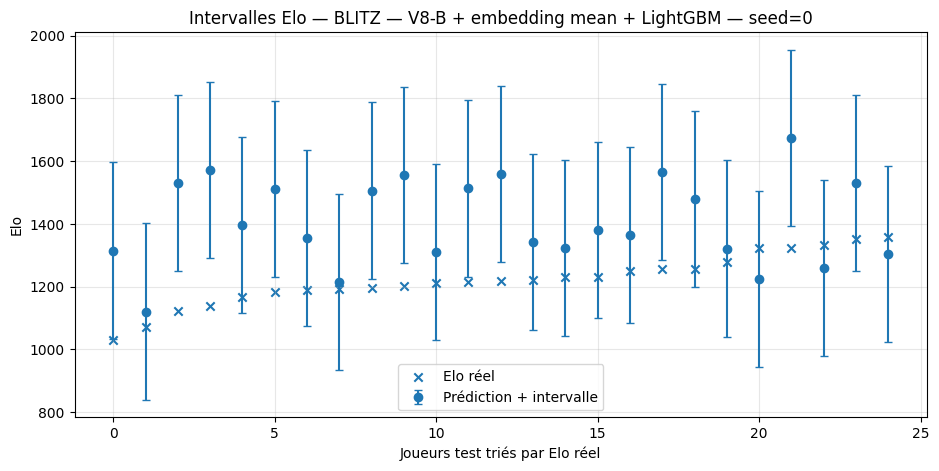

,player_id,elo,pred_elo,lower,upper,covered,interval_width,abs_error
0,138,1030.000,1315.042,1034.134,1595.950,False,561.816,285.042
1,69,1070.500,1120.811,839.902,1401.719,True,561.816,50.311
2,90,1122.000,1529.705,1248.797,1810.613,False,561.816,407.705
3,47,1140.000,1571.026,1290.118,1851.934,False,561.816,431.026
4,60,1168.000,1397.757,1116.849,1678.665,True,561.816,229.757
5,122,1183.500,1511.647,1230.739,1792.555,False,561.816,328.147
6,68,1190.000,1355.530,1074.622,1636.438,True,561.816,165.530
7,137,1192.000,1215.850,934.942,1496.758,True,561.816,23.850
8,107,1195.000,1506.528,1225.620,1787.436,False,561.816,311.528
9,70,1201.000,1555.808,1274.900,1836.716,False,561.816,354.808


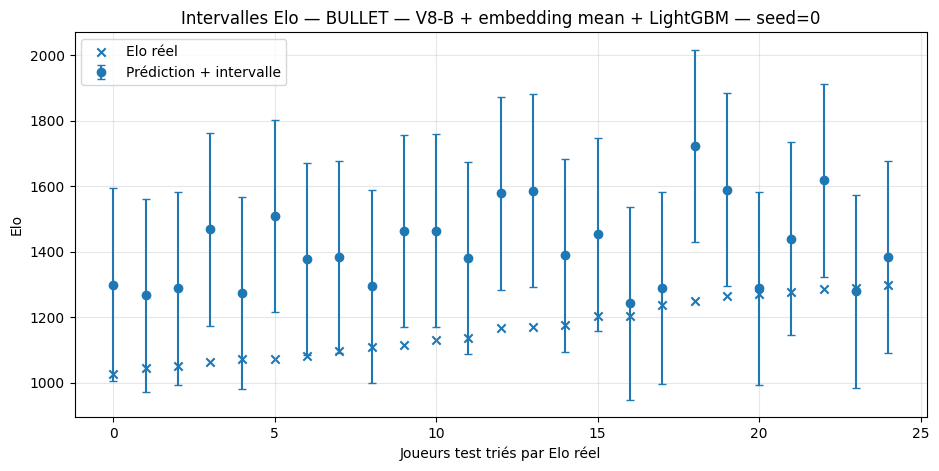

,player_id,elo,pred_elo,lower,upper,covered,interval_width,abs_error
0,51,1025.000,1299.037,1004.548,1593.526,True,588.979,274.037
1,67,1044.500,1267.427,972.938,1561.917,True,588.979,222.927
2,112,1051.000,1288.241,993.752,1582.731,True,588.979,237.241
3,124,1063.000,1468.450,1173.961,1762.940,False,588.979,405.450
4,127,1072.500,1274.078,979.589,1568.568,True,588.979,201.578
5,128,1073.500,1509.188,1214.699,1803.678,False,588.979,435.688
6,107,1083.000,1377.934,1083.444,1672.423,False,588.979,294.934
7,81,1095.500,1383.899,1089.410,1678.389,True,588.979,288.399
8,121,1108.000,1294.624,1000.135,1589.114,True,588.979,186.624
9,126,1114.000,1463.195,1168.706,1757.685,False,588.979,349.195


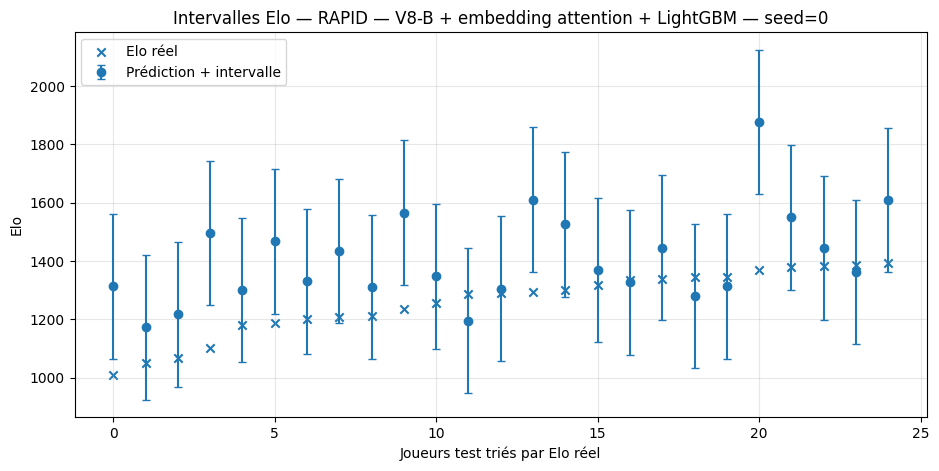

,player_id,elo,pred_elo,lower,upper,covered,interval_width,abs_error
0,83,1008.500,1313.728,1065.588,1561.868,False,496.280,305.228
1,85,1051.000,1172.495,924.355,1420.635,True,496.280,121.495
2,19,1069.000,1216.760,968.620,1464.900,True,496.280,147.760
3,31,1102.500,1496.048,1247.908,1744.189,False,496.280,393.548
4,32,1181.000,1300.979,1052.839,1549.119,True,496.280,119.979
5,14,1188.000,1467.551,1219.410,1715.691,False,496.280,279.551
6,50,1202.500,1330.847,1082.707,1578.987,True,496.280,128.347
7,9,1207.500,1434.746,1186.605,1682.886,True,496.280,227.246
8,5,1213.000,1310.999,1062.859,1559.139,True,496.280,97.999
9,47,1236.000,1565.667,1317.527,1813.807,False,496.280,329.667


In [37]:
# ============================================================
# 28. Visualisation des intervalles sur quelques joueurs test
# ============================================================

def plot_prediction_intervals(cadence, approach, seed=0, n_examples=25):
    """
    Affiche les intervalles Elo pour quelques joueurs test.
    """
    N = FINAL_MODEL_CONFIGS[cadence]["N"]
    key = (cadence, N, approach, seed)

    if key not in uncertainty_predictions:
        print(f"Prédictions absentes pour {key}")
        return

    dfp = uncertainty_predictions[key].copy()
    dfp = dfp.sort_values("elo").head(n_examples).reset_index(drop=True)

    x = np.arange(len(dfp))

    plt.figure(figsize=(11, 5))

    plt.errorbar(
        x,
        dfp["pred_elo"],
        yerr=[
            dfp["pred_elo"] - dfp["lower"],
            dfp["upper"] - dfp["pred_elo"]
        ],
        fmt="o",
        capsize=3,
        label="Prédiction + intervalle"
    )

    plt.scatter(
        x,
        dfp["elo"],
        marker="x",
        label="Elo réel"
    )

    plt.title(f"Intervalles Elo — {cadence.upper()} — {approach} — seed={seed}")
    plt.xlabel("Joueurs test triés par Elo réel")
    plt.ylabel("Elo")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    display(dfp[[
        "player_id",
        "elo",
        "pred_elo",
        "lower",
        "upper",
        "covered",
        "interval_width",
        "abs_error"
    ]].head(n_examples))


# Afficher une visualisation pour le modèle choisi de chaque cadence
for cadence, cfg in FINAL_MODEL_CONFIGS.items():
    plot_prediction_intervals(
        cadence=cadence,
        approach=cfg["approach"],
        seed=0,
        n_examples=25
    )

In [38]:
# ============================================================
# 29. Sauvegarde des résultats incertitude
# ============================================================

try:
    SAVE_DIR = CACHE_DIR
except NameError:
    SAVE_DIR = Path("./v9_cache")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

uncertainty_results_path = SAVE_DIR / "v9_uncertainty_results_by_seed.csv"
uncertainty_summary_path = SAVE_DIR / "v9_uncertainty_summary.csv"
uncertainty_gain_path = SAVE_DIR / "v9_uncertainty_gain_vs_v8.csv"

uncertainty_results_df.to_csv(uncertainty_results_path, index=False)
uncertainty_summary.to_csv(uncertainty_summary_path, index=False)
unc_gain_table.to_csv(uncertainty_gain_path, index=False)

print("Résultats sauvegardés :")
print(uncertainty_results_path)
print(uncertainty_summary_path)
print(uncertainty_gain_path)

Résultats sauvegardés :
/content/drive/MyDrive/_v9_cache/v9_uncertainty_results_by_seed.csv
/content/drive/MyDrive/_v9_cache/v9_uncertainty_summary.csv
/content/drive/MyDrive/_v9_cache/v9_uncertainty_gain_vs_v8.csv


In [39]:
# ============================================================
# 19. Sauvegarde des résultats ciblés
# ============================================================

try:
    SAVE_DIR = CACHE_DIR
except NameError:
    SAVE_DIR = Path("./v9_cache")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

focused_results_path = SAVE_DIR / "v9_focused_hybrid_results_by_seed.csv"
focused_summary_path = SAVE_DIR / "v9_focused_hybrid_summary.csv"
gain_table_path = SAVE_DIR / "v9_focused_hybrid_gain_vs_v8.csv"

focused_results_df.to_csv(focused_results_path, index=False)
focused_summary.to_csv(focused_summary_path, index=False)
gain_table.to_csv(gain_table_path, index=False)

print("Résultats sauvegardés :")
print(focused_results_path)
print(focused_summary_path)
print(gain_table_path)

Résultats sauvegardés :
/content/drive/MyDrive/_v9_cache/v9_focused_hybrid_results_by_seed.csv
/content/drive/MyDrive/_v9_cache/v9_focused_hybrid_summary.csv
/content/drive/MyDrive/_v9_cache/v9_focused_hybrid_gain_vs_v8.csv


## 7. Visualisation simple des poids d'attention

Cette cellule affiche les poids d'attention pour quelques joueurs de test à N=10.  
Un poids élevé signifie que le modèle a davantage utilisé cette partie dans l'embedding joueur.

Attention : ce n'est pas une explication causale parfaite, seulement un indice sur les parties utilisées par le modèle.



BULLET — exemples de poids attention, N=10
Joueur exemple 1: [0.008 0.09  0.171 0.026 0.106 0.171 0.145 0.094 0.02  0.171] somme= 1.0


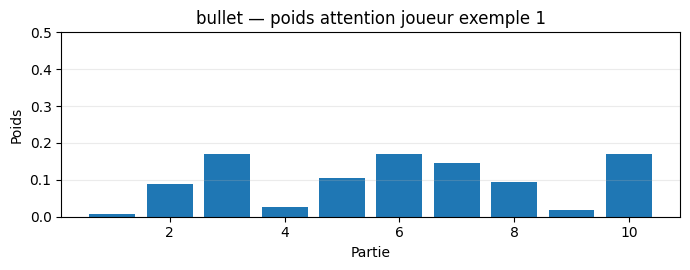

Joueur exemple 2: [0.117 0.031 0.124 0.202 0.032 0.1   0.122 0.199 0.073 0.001] somme= 1.0


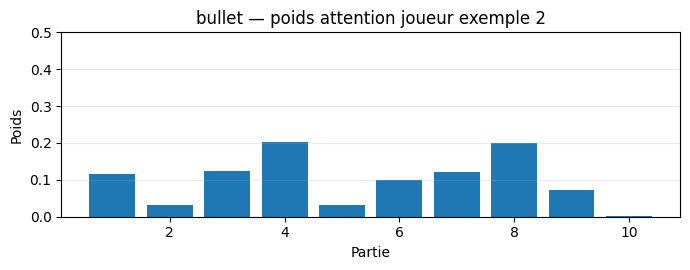

Joueur exemple 3: [0.004 0.107 0.215 0.131 0.124 0.215 0.003 0.005 0.064 0.132] somme= 1.0


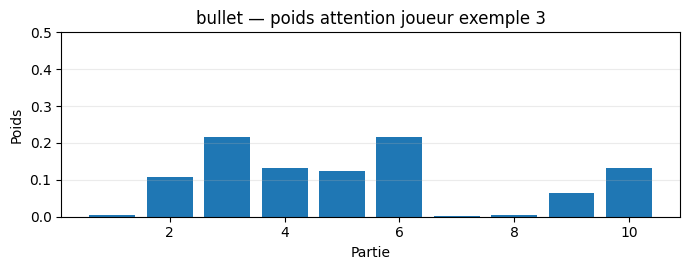


BLITZ — exemples de poids attention, N=10
Joueur exemple 1: [0.101 0.09  0.101 0.229 0.102 0.116 0.103 0.102 0.029 0.025] somme= 1.0


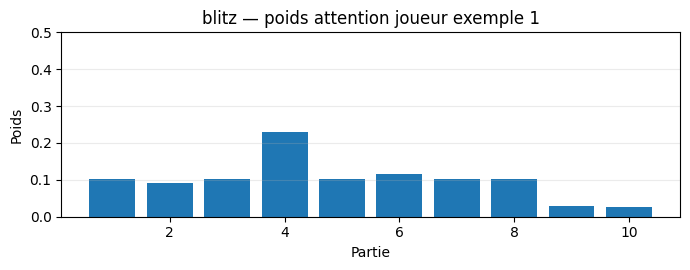

Joueur exemple 2: [0.002 0.109 0.01  0.233 0.109 0.109 0.109 0.    0.228 0.091] somme= 1.0


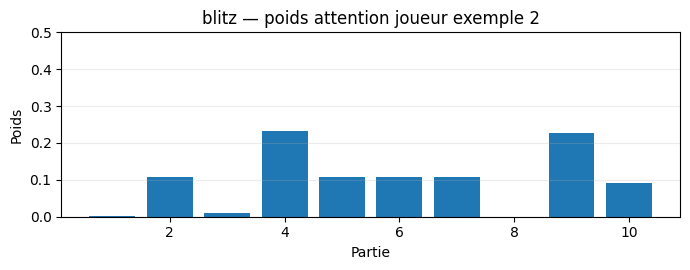

Joueur exemple 3: [0.074 0.161 0.159 0.013 0.039 0.074 0.074 0.165 0.075 0.166] somme= 1.0


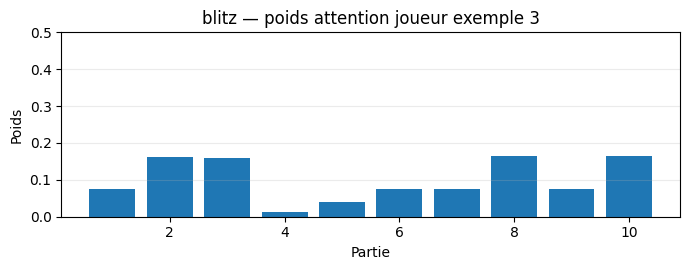


RAPID — exemples de poids attention, N=10
Joueur exemple 1: [0.023 0.127 0.038 0.127 0.032 0.13  0.032 0.191 0.109 0.191] somme= 1.0


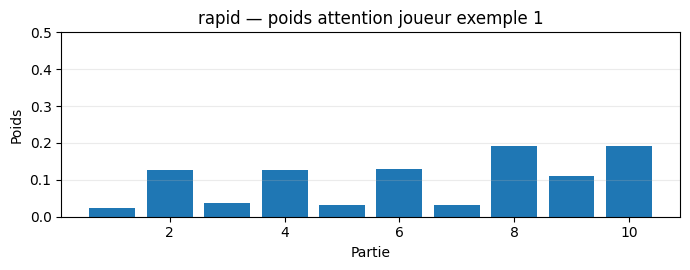

Joueur exemple 2: [0.224 0.121 0.1   0.001 0.152 0.222 0.01  0.051 0.077 0.044] somme= 1.0


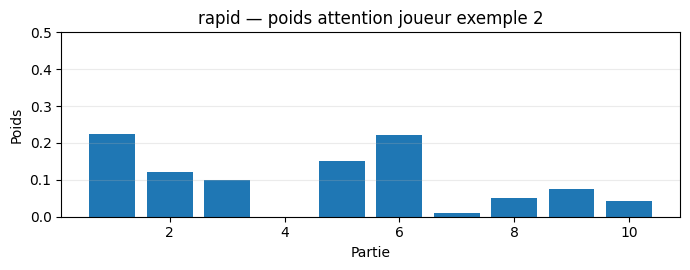

Joueur exemple 3: [0.142 0.097 0.096 0.121 0.097 0.077 0.097 0.051 0.079 0.142] somme= 1.0


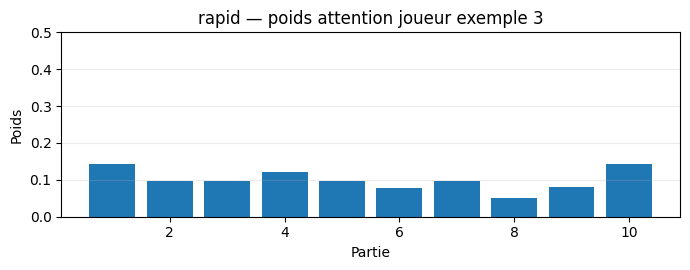

In [40]:
# ============================================================
# 10. Visualisation poids d'attention pour quelques exemples
# ============================================================

for cadence, weights in attention_weights_examples.items():
    if weights is None:
        continue
    print(f'\n{cadence.upper()} — exemples de poids attention, N=10')
    for i, w in enumerate(weights[:3]):
        valid = w[:10]
        print(f'Joueur exemple {i+1}:', np.round(valid, 3), 'somme=', round(valid.sum(), 3))
        plt.figure(figsize=(7, 2.8))
        plt.bar(np.arange(1, 11), valid)
        plt.title(f'{cadence} — poids attention joueur exemple {i+1}')
        plt.xlabel('Partie')
        plt.ylabel('Poids')
        plt.ylim(0, max(0.5, valid.max() + 0.05))
        plt.grid(True, axis='y', alpha=0.25)
        plt.tight_layout()
        plt.show()


## 12. Analyse légère des embeddings V9

Cette cellule vérifie si les embeddings sont réellement utilisés par LightGBM et à quelles familles de features V8 ils semblent se rapprocher.

In [41]:
# ============================================================
# 26. Petite analyse : qu'apportent les embeddings V9 ?
# ============================================================
# Objectif :
# - vérifier si LightGBM utilise vraiment les dimensions emb_* ;
# - voir leur poids par rapport aux familles de features V8-B ;
# - approximer ce que les embeddings captent via corrélations avec les features V8.


def classify_feature_group(feature_name: str) -> str:
    """Classe rapidement une feature dans une famille interprétable."""
    f = feature_name.lower()

    if f.startswith("emb_"):
        return "Embedding V9"

    if any(k in f for k in ["time", "clock", "remaining", "increment", "tc_", "tempo"]):
        return "Temps"

    if any(k in f for k in [
        "loss", "cp", "centipawn", "blunder", "mistake", "inaccuracy",
        "accuracy", "quality", "eval", "best", "engine"
    ]):
        return "Qualité / erreurs"

    if any(k in f for k in ["opening", "eco", "ply", "phase", "middlegame", "endgame", "game_phase"]):
        return "Phase / ouverture"

    if any(k in f for k in ["std", "var", "iqr", "p25", "p75", "median", "consistency", "stability"]):
        return "Stabilité / dispersion"

    if any(k in f for k in ["win", "draw", "loss_result", "score", "result"]):
        return "Résultat"

    if any(k in f for k in ["material", "capture", "check", "tactic", "attack", "king", "queen", "rook", "bishop", "knight", "pawn"]):
        return "Style / tactique"

    return "Autres features V8"


def build_hybrid_dataset_for_embedding_analysis(cadence, N, seed, approach):
    """
    Reconstruit le dataset utilisé pour un modèle hybride donné,
    afin de mesurer des corrélations entre emb_* et features V8-B.
    """
    obj = cadence_data[cadence]
    df_c = obj["df"]
    train_players = obj["train_players"]
    val_players = obj["val_players"]
    test_players = obj["test_players"]
    train_val_players = np.concatenate([train_players, val_players])

    player_train = build_player_dataset_exact_n(df_c, train_val_players, N, seed=seed)
    player_test = build_player_dataset_exact_n(df_c, test_players, N, seed=seed)

    if "embedding mean" in approach:
        emb_model = neural_models[cadence].get("mean", None)
    elif "embedding attention" in approach:
        emb_model = neural_models[cadence].get("attention", None)
    else:
        return pd.concat([player_train, player_test], axis=0, ignore_index=True)

    if emb_model is None:
        return None

    transform_wrapper = neural_models[cadence]["scaler"]

    trv_ds_fixed = PlayerSetDataset(
        df_c, train_val_players, GAME_FEATURE_COLS,
        max_n=MAX_N, fixed_n=N, seed=seed, scaler=transform_wrapper
    )
    te_ds_fixed = PlayerSetDataset(
        df_c, test_players, GAME_FEATURE_COLS,
        max_n=MAX_N, fixed_n=N, seed=seed, scaler=transform_wrapper
    )

    trv_loader_fixed = DataLoader(trv_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)
    te_loader_fixed = DataLoader(te_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)

    emb_train, _ = predict_and_embed(emb_model, trv_loader_fixed)
    emb_test, _ = predict_and_embed(emb_model, te_loader_fixed)

    hybrid_train = merge_embeddings(player_train, emb_train)
    hybrid_test = merge_embeddings(player_test, emb_test)

    return pd.concat([hybrid_train, hybrid_test], axis=0, ignore_index=True)


def analyze_embedding_contribution(cadence, N, seed, approach, top_k=30, top_emb_corr=3):
    key = (cadence, N, seed, approach)

    if key not in focused_models:
        print(f"Modèle absent dans focused_models : {key}")
        return None

    res = focused_models[key]
    model = res["model"]
    feature_cols = res["feature_cols"]

    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    imp_df["rank"] = np.arange(1, len(imp_df) + 1)
    imp_df["group"] = imp_df["feature"].apply(classify_feature_group)
    imp_df["is_embedding"] = imp_df["feature"].str.startswith("emb_")

    total_imp = imp_df["importance"].sum()
    if total_imp == 0:
        imp_df["importance_pct"] = 0.0
    else:
        imp_df["importance_pct"] = 100 * imp_df["importance"] / total_imp

    emb_part = imp_df[imp_df["is_embedding"]].copy()

    summary = {
        "cadence": cadence,
        "N": N,
        "seed": seed,
        "approach": approach,
        "MAE": res["MAE"],
        "R2": res["R2"],
        "n_features": len(feature_cols),
        "n_embedding_features": int(emb_part.shape[0]),
        "embedding_importance_pct": round(float(emb_part["importance_pct"].sum()), 2),
        "best_embedding_rank": int(emb_part["rank"].min()) if len(emb_part) else None,
        "embeddings_in_top_10": int(imp_df.head(10)["is_embedding"].sum()),
        "embeddings_in_top_30": int(imp_df.head(30)["is_embedding"].sum()),
    }

    print("\n" + "=" * 90)
    print(f"Analyse embeddings — {cadence.upper()} | N={N} | seed={seed}")
    print(f"Approche : {approach}")
    print(f"MAE={res['MAE']:.2f} | R²={res['R2']:.3f}")
    print("-" * 90)
    print(
        f"Poids total des embeddings : {summary['embedding_importance_pct']}% | "
        f"meilleur rang emb_* : {summary['best_embedding_rank']} | "
        f"emb_* dans top 30 : {summary['embeddings_in_top_30']}"
    )

    group_summary = (
        imp_df.groupby("group", as_index=False)
        .agg(
            importance=("importance", "sum"),
            importance_pct=("importance_pct", "sum"),
            n_features=("feature", "count"),
            best_rank=("rank", "min")
        )
        .sort_values("importance", ascending=False)
    )

    group_summary["importance_pct"] = group_summary["importance_pct"].round(2)

    print("\nImportance par famille de features :")
    display(group_summary)

    print(f"\nTop {top_k} features du modèle :")
    display(imp_df.head(top_k)[["rank", "feature", "group", "importance", "importance_pct"]])

    # Corrélations approximatives : une dimension embedding est rapprochée des familles V8
    # avec lesquelles elle varie le plus. Ce n'est pas causal, juste interprétatif.
    corr_rows = []

    try:
        analysis_df = build_hybrid_dataset_for_embedding_analysis(cadence, N, seed, approach)

        if analysis_df is not None and len(emb_part) > 0:
            top_embs = emb_part.head(top_emb_corr)["feature"].tolist()
            usable_cols = [c for c in feature_cols if c in analysis_df.columns]
            v8_cols = [c for c in usable_cols if not c.startswith("emb_") and c != "elo"]

            for emb in top_embs:
                if emb not in analysis_df.columns:
                    continue

                corr_candidates = []
                for c in v8_cols:
                    if analysis_df[c].nunique(dropna=True) <= 1:
                        continue
                    corr = analysis_df[[emb, c]].corr(method="spearman").iloc[0, 1]
                    if pd.notna(corr):
                        corr_candidates.append((c, abs(float(corr)), float(corr), classify_feature_group(c)))

                top_corr = sorted(corr_candidates, key=lambda x: x[1], reverse=True)[:8]
                for c, abs_corr, corr, group in top_corr:
                    corr_rows.append({
                        "embedding": emb,
                        "v8_feature_corrélée": c,
                        "famille": group,
                        "corr_spearman": round(corr, 3),
                        "abs_corr": round(abs_corr, 3),
                    })

        if corr_rows:
            corr_df = pd.DataFrame(corr_rows)
            print("\nFeatures V8 les plus corrélées aux dimensions d'embedding importantes :")
            display(corr_df)
        else:
            corr_df = pd.DataFrame()
            print("\nCorrélations embedding ↔ V8 non calculées ou non disponibles.")

    except Exception as e:
        corr_df = pd.DataFrame()
        print(f"\nCorrélations non calculées à cause de : {e}")

    # Mini interprétation automatique
    top_groups = group_summary.head(3)["group"].tolist()
    if summary["embedding_importance_pct"] >= 15:
        emb_read = "les embeddings contribuent fortement au modèle final"
    elif summary["embedding_importance_pct"] >= 5:
        emb_read = "les embeddings apportent un signal complémentaire, mais pas dominant"
    else:
        emb_read = "les embeddings sont peu utilisés par rapport aux features V8-B"

    print("\nLecture rapide :")
    print(f"- {emb_read}.")
    print(f"- Les familles dominantes sont : {', '.join(top_groups)}.")
    print("- Si les corrélations emb_* sont réparties sur plusieurs familles, cela suggère que l'embedding mélange plusieurs signaux : qualité, temps, stabilité, style, etc.")

    return {
        "summary": summary,
        "importance": imp_df,
        "group_summary": group_summary,
        "correlations": corr_df,
    }


# ------------------------------------------------------------
# Lancement automatique : meilleure approche hybride pour chaque cadence.
# On privilégie le régime faible N (N <= 10), plus réaliste pour le projet.
# ------------------------------------------------------------
EMBEDDING_ANALYSIS_RESULTS = {}
analysis_rows = []

if "focused_summary" not in globals():
    print("focused_summary est introuvable. Exécute d'abord les cellules d'expérience V9.")
elif "focused_models" not in globals():
    print("focused_models est introuvable. Exécute d'abord les cellules d'expérience V9.")
else:
    candidate_summary = focused_summary[
        (focused_summary["approach"].str.contains("embedding", na=False))
        & (focused_summary["N"] <= 10)
    ].copy()

    if len(candidate_summary) == 0:
        print("Aucune approche embedding trouvée pour N <= 10.")
    else:
        for cadence in candidate_summary["cadence"].unique():
            row = (
                candidate_summary[candidate_summary["cadence"] == cadence]
                .sort_values("MAE_mean")
                .iloc[0]
            )

            cadence = row["cadence"]
            N = int(row["N"])
            approach = row["approach"]
            seed = FOCUSED_SEEDS[0]

            out = analyze_embedding_contribution(
                cadence=cadence,
                N=N,
                seed=seed,
                approach=approach,
                top_k=30,
                top_emb_corr=3
            )

            if out is not None:
                EMBEDDING_ANALYSIS_RESULTS[(cadence, N, seed, approach)] = out
                analysis_rows.append(out["summary"])

        if analysis_rows:
            embedding_analysis_summary = pd.DataFrame(analysis_rows)
            print("\n" + "=" * 90)
            print("Résumé global de l'utilisation des embeddings")
            display(embedding_analysis_summary)



Analyse embeddings — BLITZ | N=10 | seed=0
Approche : V8-B + embedding mean + LightGBM
MAE=161.28 | R²=0.579
------------------------------------------------------------------------------------------
Poids total des embeddings : 10.01% | meilleur rang emb_* : 16 | emb_* dans top 30 : 1

Importance par famille de features :


,group,importance,importance_pct,n_features,best_rank
3,Qualité / erreurs,2227,47.350,58,1
7,Temps,1140,24.240,33,7
1,Embedding V9,471,10.010,48,16
5,Stabilité / dispersion,438,9.310,11,8
0,Autres features V8,137,2.910,4,9
2,Phase / ouverture,122,2.590,2,6
4,Résultat,98,2.080,2,4
6,Style / tactique,70,1.490,1,10



Top 30 features du modèle :


,rank,feature,group,importance,importance_pct
0,1,loss_opening_iqr_mean,Qualité / erreurs,79,1.680
1,2,loss_drift_end_vs_start_median,Qualité / erreurs,78,1.659
2,3,loss_when_losing_mean,Qualité / erreurs,75,1.595
3,4,n_moves_winning_mean,Résultat,74,1.573
4,5,blunder_pressure_ratio_mean,Qualité / erreurs,73,1.552
5,6,ply_count_iqr,Phase / ouverture,73,1.552
6,7,time_std_s_std,Temps,73,1.552
7,8,good_fast_move_rate_smooth_median,Stabilité / dispersion,72,1.531
8,9,n_moves_equal_mean,Autres features V8,70,1.488
9,10,rate_capture_mean,Style / tactique,70,1.488


✓ player_features V8 : 560 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features

Features V8 les plus corrélées aux dimensions d'embedding importantes :


...

,rank,feature,group,importance,importance_pct
0,1,emb_38,Embedding V9,73,1.760
1,2,loss_opening_iqr_mean,Qualité / erreurs,71,1.712
2,3,rate_blunder_opening_smooth_mean,Qualité / erreurs,67,1.616
3,4,loss_log_mean_std,Qualité / erreurs,66,1.592
4,5,loss_max_std,Qualité / erreurs,64,1.543
5,6,blunder_low_time_rate_smooth_iqr,Temps,64,1.543
6,7,emb_17,Embedding V9,64,1.543
7,8,ply_count_mean,Phase / ouverture,62,1.495
8,9,loss_opening_median_mean,Qualité / erreurs,59,1.423
9,10,emb_02,Embedding V9,58,1.399


✓ player_features V8 : 388 joueurs × 216 features
✓ player_features V8 : 98 joueurs × 216 features

Features V8 les plus corrélées aux dimensions d'embedding importantes :


,embedding,v8_feature_corrélée,famille,corr_spearman,abs_corr
0,emb_38,loss_opening_mean_median,Qualité / erreurs,-0.617,0.617
1,emb_38,loss_opening_iqr_mean,Qualité / erreurs,-0.606,0.606
2,emb_38,rate_blunder_smooth_mean,Qualité / erreurs,-0.596,0.596
3,emb_38,loss_opening_median_mean,Qualité / erreurs,-0.589,0.589
4,emb_38,rate_blunder_when_equal_smooth_mean,Qualité / erreurs,-0.584,0.584
5,emb_38,rate_good_mean,Autres features V8,0.572,0.572
6,emb_38,loss_opening_iqr_median,Qualité / erreurs,-0.571,0.571
7,emb_38,rate_loss_gt200_mean,Qualité / erreurs,-0.569,0.569
8,emb_17,n_moves_equal_median,Stabilité / dispersion,0.472,0.472
9,emb_17,rate_blunder_when_equal_smooth_mean,Qualité / erreurs,-0.399,0.399



Lecture rapide :
- les embeddings contribuent fortement au modèle final.
- Les familles dominantes sont : Qualité / erreurs, Temps, Embedding V9.
- Si les corrélations emb_* sont réparties sur plusieurs familles, cela suggère que l'embedding mélange plusieurs signaux : qualité, temps, stabilité, style, etc.

Résumé global de l'utilisation des embeddings


,cadence,N,seed,approach,MAE,R2,n_features,n_embedding_features,embedding_importance_pct,best_embedding_rank,embeddings_in_top_10,embeddings_in_top_30
0,blitz,10,0,V8-B + embedding mean + LightGBM,161.277,0.579,159,48,10.010,16,0,1
1,bullet,10,0,V8-B + embedding mean + LightGBM,172.096,0.564,185,48,9.540,10,1,2
2,rapid,10,0,V8-B + embedding attention + LightGBM,139.698,0.558,151,48,18.780,1,3,5


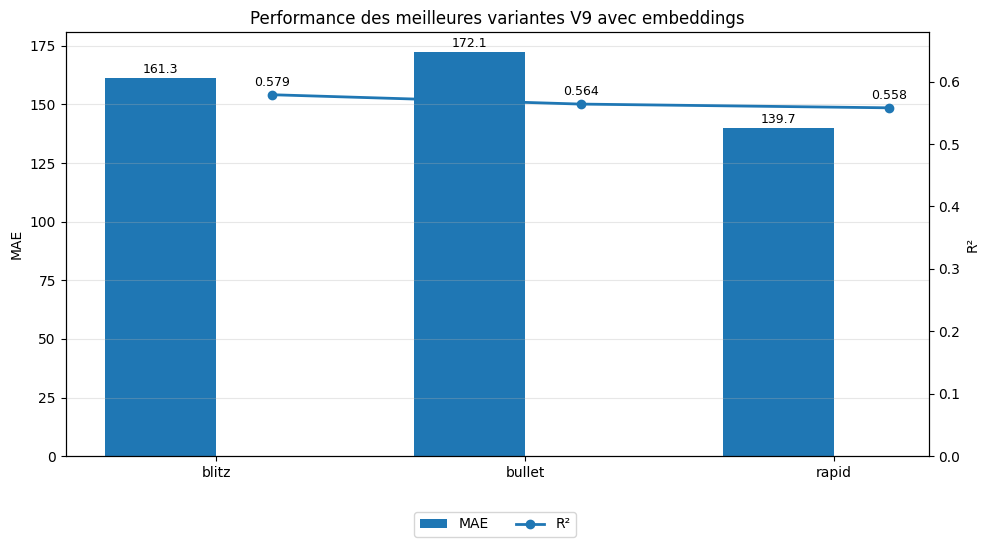

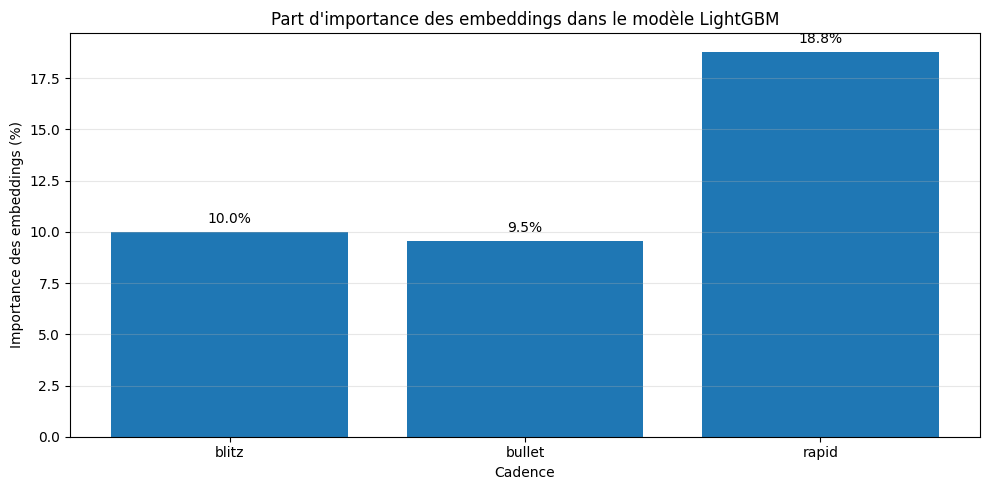

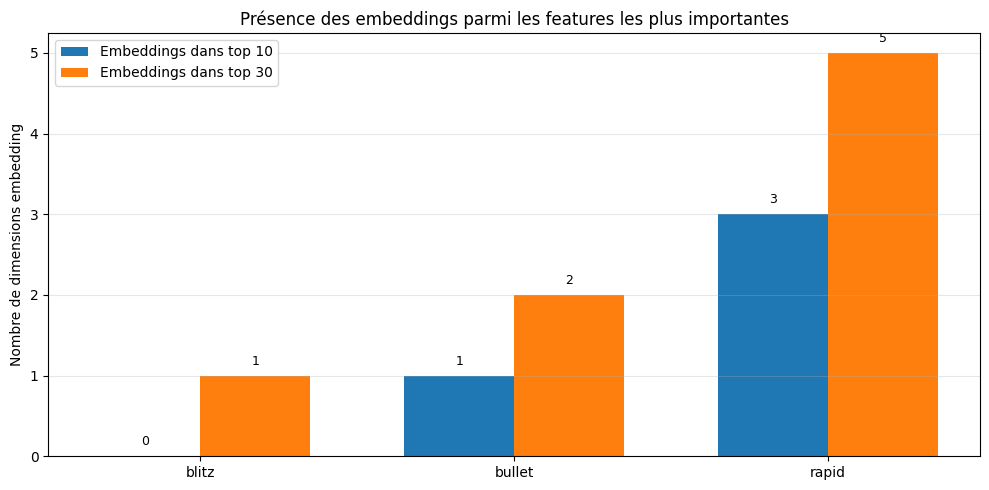

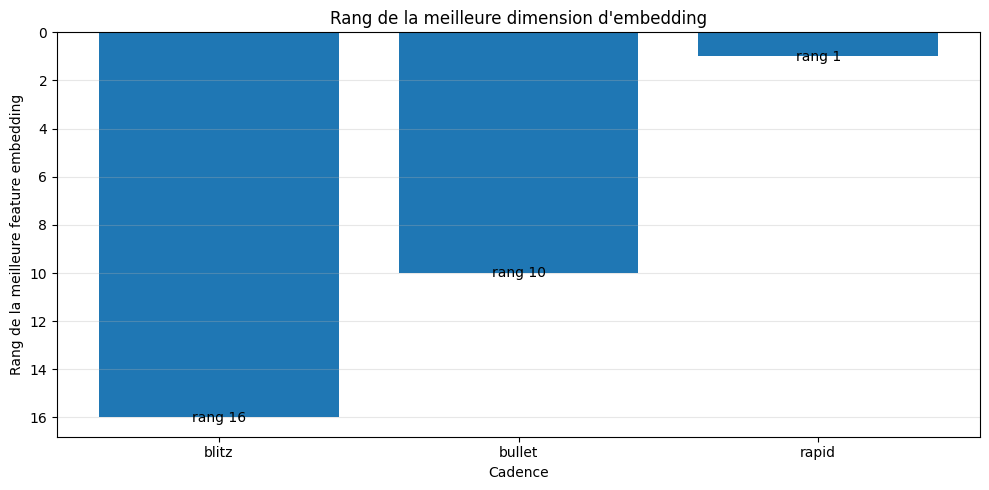


Résumé rapide de l'utilisation des embeddings
- BLITZ : MAE=161.3, R²=0.579, importance embeddings=10.0%, meilleur rang embedding=16, top10=0, top30=1.
- BULLET : MAE=172.1, R²=0.564, importance embeddings=9.5%, meilleur rang embedding=10, top10=1, top30=2.
- RAPID : MAE=139.7, R²=0.558, importance embeddings=18.8%, meilleur rang embedding=1, top10=3, top30=5.


In [42]:
# ============================================================
# Graphe résumé — utilisation des embeddings par cadence
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Si le DataFrame existe déjà après la cellule précédente, on le réutilise.
# Sinon, on le reconstruit directement avec les valeurs affichées.
if 'embedding_usage_summary' not in globals():
    embedding_usage_summary = pd.DataFrame([
        {
            'cadence': 'blitz',
            'N': 10,
            'seed': 0,
            'approach': 'V8-B + embedding mean + LightGBM',
            'MAE': 161.277,
            'R2': 0.579,
            'n_features': 159,
            'n_embedding_features': 48,
            'embedding_importance_pct': 10.010,
            'best_embedding_rank': 16,
            'embeddings_in_top_10': 0,
            'embeddings_in_top_30': 1,
        },
        {
            'cadence': 'bullet',
            'N': 10,
            'seed': 0,
            'approach': 'V8-B + embedding mean + LightGBM',
            'MAE': 172.096,
            'R2': 0.564,
            'n_features': 185,
            'n_embedding_features': 48,
            'embedding_importance_pct': 9.540,
            'best_embedding_rank': 10,
            'embeddings_in_top_10': 1,
            'embeddings_in_top_30': 2,
        },
        {
            'cadence': 'rapid',
            'N': 10,
            'seed': 0,
            'approach': 'V8-B + embedding attention + LightGBM',
            'MAE': 139.698,
            'R2': 0.558,
            'n_features': 151,
            'n_embedding_features': 48,
            'embedding_importance_pct': 18.780,
            'best_embedding_rank': 1,
            'embeddings_in_top_10': 3,
            'embeddings_in_top_30': 5,
        },
    ])

df_plot = embedding_usage_summary.copy()
df_plot = df_plot.sort_values('cadence')

cadences = df_plot['cadence'].tolist()
x = np.arange(len(cadences))

# ------------------------------------------------------------
# Figure 1 — Performances MAE / R²
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(x - 0.18, df_plot['MAE'], width=0.36, label='MAE')
ax1.set_ylabel('MAE')
ax1.set_xticks(x)
ax1.set_xticklabels(cadences)
ax1.set_title('Performance des meilleures variantes V9 avec embeddings')
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()
line = ax2.plot(
    x + 0.18,
    df_plot['R2'],
    marker='o',
    linewidth=2,
    label='R²'
)
ax2.set_ylabel('R²')
ax2.set_ylim(0, max(df_plot['R2']) + 0.1)

for i, r2 in enumerate(df_plot['R2']):
    ax2.text(
        x[i] + 0.18,
        r2 + 0.01,
        f'{r2:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figure 2 — Importance des embeddings
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

bars = plt.bar(
    df_plot['cadence'],
    df_plot['embedding_importance_pct']
)

plt.title("Part d'importance des embeddings dans le modèle LightGBM")
plt.ylabel("Importance des embeddings (%)")
plt.xlabel("Cadence")
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figure 3 — Présence des embeddings dans les top features
# ------------------------------------------------------------
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    df_plot['embeddings_in_top_10'],
    width,
    label='Embeddings dans top 10'
)

plt.bar(
    x + width / 2,
    df_plot['embeddings_in_top_30'],
    width,
    label='Embeddings dans top 30'
)

plt.xticks(x, cadences)
plt.ylabel("Nombre de dimensions embedding")
plt.title("Présence des embeddings parmi les features les plus importantes")
plt.grid(axis='y', alpha=0.3)
plt.legend()

for i, row in df_plot.iterrows():
    idx = cadences.index(row['cadence'])

    plt.text(
        idx - width / 2,
        row['embeddings_in_top_10'] + 0.1,
        str(int(row['embeddings_in_top_10'])),
        ha='center',
        va='bottom',
        fontsize=9
    )

    plt.text(
        idx + width / 2,
        row['embeddings_in_top_30'] + 0.1,
        str(int(row['embeddings_in_top_30'])),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Figure 4 — Rang de la meilleure dimension embedding
# Plus le rang est petit, plus l'embedding est important
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

bars = plt.bar(
    df_plot['cadence'],
    df_plot['best_embedding_rank']
)

plt.title("Rang de la meilleure dimension d'embedding")
plt.ylabel("Rang de la meilleure feature embedding")
plt.xlabel("Cadence")
plt.gca().invert_yaxis()
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f'rang {int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Résumé textuel automatique
# ------------------------------------------------------------
print("\n" + "="*70)
print("Résumé rapide de l'utilisation des embeddings")
print("="*70)

for _, row in df_plot.iterrows():
    print(
        f"- {row['cadence'].upper()} : "
        f"MAE={row['MAE']:.1f}, R²={row['R2']:.3f}, "
        f"importance embeddings={row['embedding_importance_pct']:.1f}%, "
        f"meilleur rang embedding={int(row['best_embedding_rank'])}, "
        f"top10={int(row['embeddings_in_top_10'])}, "
        f"top30={int(row['embeddings_in_top_30'])}."
    )